# KGBN manuscript

This notebook contains the code for the analysis of the KGBN manuscript.  
Note that this only includes the preprocessing and analysis of the data.  
The actual optimization is done in Hyak (UW's high performance computing resource).  

# Import

In [1]:
import sys
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
import seaborn as sns
from matplotlib.colors import ListedColormap

import KGBN


network_file = 'inputs/Palma2021.txt'

drugs = [
"Venetoclax",
"Entospletinib",
"Ibrutinib",
"Trametinib",
"Selumetinib",
"Midostaurin",
]

drug2target = {
    'Venetoclax': ['BCL2'], 
    'Ibrutinib': ['BTK'],
    'Entospletinib': ['SYK'],
    'Selumetinib': ['MAP2K1','MAP2K2'],
    'Midostaurin': ['FLT3','KIT'],
    }

# AUC by mutation profile with mean ± s.d. boxes (Train vs Test), with ANOVA p-values shown, and 'combined' mode option
from scipy.stats import f_oneway

def AUC_by_mutation_profile(df_plot, combined=False):
    def normalize_profile_text(p):
        if isinstance(p, (set, frozenset, list, tuple)):
            genes = sorted(map(str, p))
        else:
            s = re.sub(r'[\{\}]', '', str(p))
            genes = sorted([g.strip() for g in s.split(',') if g.strip()])
        return "+".join(genes) if genes else "None"

    # Merge cohort information
    df_plot = df_plot.copy()  # so we don't modify original
    df_plot["profile_label"] = df_plot["mutation_profile"].apply(normalize_profile_text)

    for drug in sorted(df_plot["inhibitor"].unique()):
        print(f"Drug:{drug}")
        sub = df_plot[df_plot["inhibitor"] == drug].copy()
        # Grouping function
        def get_profile_stats(data):
            return data.groupby("profile_label")['auc'].agg(['mean', 'std', 'count']).reset_index()

        all_profiles = sorted(df_plot["profile_label"].unique())

        if len(all_profiles) == 0:
            continue

        # Prepare ANOVA for each group
        def get_anova_p(data, labels=all_profiles):
            groups = [data[data['profile_label']==profile]['auc'].values for profile in labels]
            groups = [g for g in groups if len(g)>1]  # ANOVA requires n>1 per group
            if len(groups) <= 1:
                return None
            try:
                F, p = f_oneway(*groups)
                return p
            except Exception:
                return None

        if combined:
            stats = get_profile_stats(sub)
            pval = get_anova_p(sub)
            fig, ax = plt.subplots(1,1, figsize=(max(6, len(all_profiles) * 0.7), 6))
            positions = range(len(all_profiles))

            # Plot all data
            for i, profile in enumerate(all_profiles):
                profile_data = sub[sub['profile_label'] == profile]
                if len(profile_data) > 0:
                    x_jitter = np.random.normal(i, 0.08, len(profile_data))
                    ax.scatter(x_jitter, profile_data['auc'], alpha=0.5, s=25, color='steelblue')

            # Plot mean ± s.d. boxes
            for i, profile in enumerate(all_profiles):
                local_stats = stats[stats['profile_label'] == profile]
                if len(local_stats) > 0:
                    mean_val = local_stats['mean'].values[0]
                    std_val = local_stats['std'].values[0]
                    count = local_stats['count'].values[0]
                    box_width = 0.35
                    ax.add_patch(plt.Rectangle((i - box_width/2, mean_val - std_val),
                                                box_width, 2*std_val,
                                                facecolor='lightskyblue', alpha=0.4,
                                                linewidth=1.5, edgecolor='dodgerblue'))
                    ax.plot([i - box_width/2, i + box_width/2], [mean_val, mean_val],
                            color='darkblue', linewidth=2, zorder=10)
                    ax.text(i, mean_val - std_val - 3, f'n={int(count)}',
                            ha='center', va='top', fontsize=7)

            ax.set_xticks(positions)
            ax.set_xticklabels(all_profiles, rotation=45, ha='right', fontsize=8)
            ax.set_ylabel('AUC')
            ax.set_title(f'{drug} - Combined (All Cohorts)')
            ax.grid(axis='y', alpha=0.3)

            # Annotate ANOVA p-value
            if pval is not None:
                print(f'ANOVA p={pval:.2e}')
                ax.annotate(f'ANOVA p={pval:.2e}', xy=(1,1), xycoords='axes fraction',
                            xytext=(-10,-10), textcoords='offset points',
                            ha='right', va='top', fontsize=10, fontweight='bold',
                            bbox=dict(boxstyle="round,pad=0.2", fc="w", ec="none", alpha=0.7))
            plt.tight_layout()
            plt.show()
        else:
            # Split by cohort
            train_data = sub[sub['cohort'] == 'Waves1+2'].copy()
            test_data = sub[sub['cohort'] == 'Waves3+4'].copy()

            train_stats = get_profile_stats(train_data)
            test_stats = get_profile_stats(test_data)
            positions = range(len(all_profiles))

            # ANOVA
            pval_train = get_anova_p(train_data)
            pval_test = get_anova_p(test_data)

            # Plot with 2 subplots
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(6, len(all_profiles) * 0.7), 8))

            # Plot TRAIN
            for i, profile in enumerate(all_profiles):
                profile_data = train_data[train_data['profile_label'] == profile]
                if len(profile_data) > 0:
                    x_jitter = np.random.normal(i, 0.08, len(profile_data))
                    ax1.scatter(x_jitter, profile_data['auc'], alpha=0.5, s=25, color='steelblue')
            for i, profile in enumerate(all_profiles):
                stats = train_stats[train_stats['profile_label'] == profile]
                if len(stats) > 0:
                    mean_val = stats['mean'].values[0]
                    std_val = stats['std'].values[0]
                    count = stats['count'].values[0]
                    box_width = 0.35
                    ax1.add_patch(plt.Rectangle((i - box_width/2, mean_val - std_val),
                                                box_width, 2*std_val,
                                                facecolor='lightcoral', alpha=0.4,
                                                linewidth=1.5, edgecolor='coral'))
                    ax1.plot([i - box_width/2, i + box_width/2], [mean_val, mean_val],
                             color='darkred', linewidth=2, zorder=10)
                    ax1.text(i, mean_val - std_val - 3, f'n={int(count)}',
                             ha='center', va='top', fontsize=7)
            ax1.set_xticks(positions)
            ax1.set_xticklabels(all_profiles, rotation=45, ha='right', fontsize=8)
            ax1.set_ylabel('AUC')
            ax1.set_title(f'{drug} - TRAIN (Waves1+2)')
            ax1.grid(axis='y', alpha=0.3)
            # ANOVA p
            if pval_train is not None:
                ax1.annotate(f'ANOVA p={pval_train:.2e}', xy=(1,1), xycoords='axes fraction',
                             xytext=(-10,-10), textcoords='offset points',
                             ha='right', va='top', fontsize=10, fontweight='bold',
                             bbox=dict(boxstyle="round,pad=0.2", fc="w", ec="none", alpha=0.7))

            # Plot TEST
            for i, profile in enumerate(all_profiles):
                profile_data = test_data[test_data['profile_label'] == profile]
                if len(profile_data) > 0:
                    x_jitter = np.random.normal(i, 0.08, len(profile_data))
                    ax2.scatter(x_jitter, profile_data['auc'], alpha=0.5, s=25, color='steelblue')
            for i, profile in enumerate(all_profiles):
                stats = test_stats[test_stats['profile_label'] == profile]
                if len(stats) > 0:
                    mean_val = stats['mean'].values[0]
                    std_val = stats['std'].values[0]
                    count = stats['count'].values[0]
                    box_width = 0.35
                    ax2.add_patch(plt.Rectangle((i - box_width/2, mean_val - std_val),
                                                box_width, 2*std_val,
                                                facecolor='lightskyblue', alpha=0.4,
                                                linewidth=1.5, edgecolor='dodgerblue'))
                    ax2.plot([i - box_width/2, i + box_width/2], [mean_val, mean_val],
                             color='darkblue', linewidth=2, zorder=10)
                    ax2.text(i, mean_val - std_val - 3, f'n={int(count)}',
                             ha='center', va='top', fontsize=7)
            ax2.set_xticks(positions)
            ax2.set_xticklabels(all_profiles, rotation=45, ha='right', fontsize=8)
            ax2.set_xlabel('Mutation Profile')
            ax2.set_ylabel('AUC')
            ax2.set_title(f'{drug} - TEST (Waves3+4)')
            ax2.grid(axis='y', alpha=0.3)
            # ANOVA p
            if pval_test is not None:
                ax2.annotate(f'ANOVA p={pval_test:.2e}', xy=(1,1), xycoords='axes fraction',
                             xytext=(-10,-10), textcoords='offset points',
                             ha='right', va='top', fontsize=10, fontweight='bold',
                             bbox=dict(boxstyle="round,pad=0.2", fc="w", ec="none", alpha=0.7))
            plt.tight_layout()
            plt.show()

def create_experimental_data(df, cohort='Waves1+2',
                            mutation_genes=['FLT3_ITD', 'NPM1', 'DNMT3A'], 
                            inhibitors=['Venetoclax', 'Ibrutinib', 'Entospletinib'],
                            drug2target=None,
                            gene_to_class=None,
                            output_file='beataml_experiments.csv'):
    """
    Create experimental data CSV from BeatAML drug response data.
    
    Parameters:
    - df: DataFrame with mutation_profile, inhibitor, and auc columns
    - cohort: 'Waves1+2' or 'Waves3+4' or None
    - mutation_genes: List of genes
    - inhibitors: List of drug names
    - output_file: Output CSV filename
    
    Note: Oncogenes become Stimuli, TSGs become Inhibitors based on gene_to_class
    """
    
    # Drug to target mapping
    if drug2target is None:
        drug2target = {
            'Venetoclax': ['BCL2'], 
            'Ibrutinib': ['BTK'], 
            'Entospletinib': ['SYK'],
            'Trametinib': ['MAP2K1','MAP2K2'],
            'Selumetinib': ['MAP2K1','MAP2K2'],
            'Midostaurin': ['FLT3','KIT'],
            }
    if gene_to_class is None:
        # mutation class
        classification = pd.read_csv("inputs/Palma_class_extended.csv")
        gene_to_class = dict(zip(classification['symbol'], classification['class']))
    # Normalize profile text for comparison
    def normalize_profile_text(p):
        if isinstance(p, (set, frozenset, list, tuple)):
            genes = sorted(map(str, p))
        else:
            s = re.sub(r'[\\{\\}]', '', str(p))
            genes = sorted([g.strip() for g in s.split(',') if g.strip()])
        return set(genes) if genes else set()
    
    df_work = df.copy()
    if cohort:
        df_work = df_work[df_work['cohort'] == cohort]
    df_work['profile_set'] = df_work['mutation_profile'].apply(normalize_profile_text)
    
    # Generate all mutation profile combinations
    from itertools import combinations
    all_profiles = []
    for r in range(len(mutation_genes) + 1):
        for combo in combinations(mutation_genes, r):
            all_profiles.append(set(combo))
    
    print(f"\\nGenerating data for {len(all_profiles)} profiles × {len(inhibitors)} drugs = {len(all_profiles) * len(inhibitors)} experiments")
    
    # Create experiment rows
    experiments = []
    exp_id = 1
    
    for profile in all_profiles:
        for drug in inhibitors:
            # Filter data for this profile and drug
            matching_data = df_work[
                (df_work['profile_set'] == profile) & 
                (df_work['inhibitor'].str.contains(drug, case=False, na=False))
            ]
            
            if len(matching_data) == 0:
                continue
            
            # Calculate average AUC
            avg_auc = matching_data['auc'].mean()
            std_auc = matching_data['auc'].std()
            n_patients = len(matching_data)
            
            # Classify genes as oncogenes or TSGs
            oncogenes = []
            tsgs = []
            
            for gene in profile:
                if gene == 'FLT3_ITD':
                    gene = 'FLT3'
                gene_class = gene_to_class.get(gene, 'unknown')
                if gene_class == 'oncogene':
                    oncogenes.append(gene)
                elif gene_class == 'TSG':
                    tsgs.append(gene)
                else:
                    print(f"Warning: Unknown classification for {gene}, treating as oncogene")
                    oncogenes.append(gene)
            
            # Oncogenes → Stimuli (activate)
            stimuli = ','.join(sorted(oncogenes)) if oncogenes else ''
            stimuli_efficacy = ','.join(['1'] * len(oncogenes)) if oncogenes else ''
            
            # TSGs + Drug target → Inhibitors (knockdown)
            target = drug2target.get(drug, '')
            if not target:
                print(f"Warning: No target mapping for {drug}, skipping...")
                continue
            
            all_inhibitors = sorted(tsgs + target)
            inhibitors_str = ','.join(all_inhibitors)
            inhibitors_efficacy = ','.join(['1'] * len(all_inhibitors))
            
            measured_nodes = 'AUC'
            measured_values = f'{avg_auc:.2f}'

            mutation_profile = ','.join(sorted(profile)) if profile else 'No mutation'
            
            experiments.append({
                'Experiments': exp_id,
                'Stimuli': stimuli,
                'Stimuli_efficacy': stimuli_efficacy,
                'Inhibitors': inhibitors_str,
                'Inhibitors_efficacy': inhibitors_efficacy,
                'Measured_nodes': measured_nodes,
                'Measured_values': measured_values,
                'n_patients': n_patients,
                'std': f'{std_auc:.2f}',
                'drug': drug,
                'mutation_profile': mutation_profile
            })
            
            exp_id += 1
    
    # Create DataFrame
    exp_df = pd.DataFrame(experiments)
    
    # Save to CSV
    exp_df.to_csv(output_file, index=False)
    
    print(f"\\nSaved {len(exp_df)} experiments to {output_file}")
    print(f"\\nSummary by drug:")
    print(exp_df.groupby('drug').agg({
        'n_patients': 'sum',
        'Measured_values': lambda x: f"{pd.to_numeric(x).mean():.2f}±{pd.to_numeric(x).std():.2f}"
    }).rename(columns={'Measured_values': 'Mean AUC±SD', 'n_patients': 'Total patients'}))
    
    return exp_df

# BeatAML data

This follows the exact approach from the BeatAML2 manuscript   
(see https://github.com/biodev/beataml2_manuscript/blob/main/R/preprocess.R, function `mutation.only.dataset()`):

1. Filter clinical data: Only samples with `manuscript_dnaseq == 'yes'`
2. Create binary mutation matrix: Rows = patients (ptid), Columns = genes, Values = 1 (mutation present) or 0 (absent)
3. Add consensus annotations: Override with manual annotations from clinical file for:
   - NPM1 (from NPM1 column: positive = 1)
   - FLT3_ITD (from FLT3-ITD column: positive = 1)
   - RUNX1 (from RUNX1 column: not NA = 1)
   - ASXL1 (from ASXL1 column: not NA = 1)
   - TP53 (from TP53 column: not NA = 1)

In [2]:
# BeatAML data
drug_response = pd.read_csv("https://media.githubusercontent.com/media/biodev/beataml2.0_data/main/beataml_probit_curve_fits_v4_dbgap.txt", sep='\t')
mutations = pd.read_csv("https://github.com/biodev/beataml2.0_data/raw/main/beataml_wes_wv1to4_mutations_dbgap.txt", sep='\t')
clinical = pd.read_excel("https://github.com/biodev/beataml2.0_data/raw/main/beataml_wv1to4_clinical.xlsx")

# Filter clinical data to those with DNA sequencing
dna_clin = clinical[clinical['manuscript_dnaseq'] == 'yes'].copy()

# Merge with clinical data 
dna_clin['ptid'] = 'pt' + dna_clin['dbgap_subject_id'].astype(str)
muts_merged = pd.merge(
    dna_clin[['ptid', 'dbgap_dnaseq_sample', 'cohort', 'NPM1', 'FLT3-ITD', 'RUNX1', 'ASXL1', 'TP53']],
    mutations,
    left_on='dbgap_dnaseq_sample',
    right_on='dbgap_sample_id',
    how='inner'
)
# Create binary mutation matrix (patient x gene): if a patient has any mutation in a gene, mark as 1
muts_merged['value'] = 1
mutation_matrix = muts_merged.pivot_table(
    index='ptid',
    columns='symbol',
    values='value',
    aggfunc='max',  # If multiple mutations in same gene, still just 1
    fill_value=0
)
# Add manual annotations from clinical data (NPM1, FLT3-ITD, RUNX1, ASXL1, TP53)
manual_muts = dna_clin.set_index('ptid')[['NPM1', 'FLT3-ITD', 'RUNX1', 'ASXL1', 'TP53']].copy()
manual_muts['NPM1'] = (manual_muts['NPM1'] == 'positive').astype(int)
manual_muts['FLT3_ITD'] = (manual_muts['FLT3-ITD'] == 'positive').astype(int)
manual_muts['RUNX1'] = manual_muts['RUNX1'].notna().astype(int)
manual_muts['ASXL1'] = manual_muts['ASXL1'].notna().astype(int)
manual_muts['TP53'] = manual_muts['TP53'].notna().astype(int)
manual_muts = manual_muts[['NPM1', 'FLT3_ITD', 'RUNX1', 'ASXL1', 'TP53']]

# some patients in clinical file don't have WES mutations
missing_patients = list(set(manual_muts.index) - set(mutation_matrix.index))
if missing_patients:
    missing_df = pd.DataFrame(0, index=missing_patients, columns=mutation_matrix.columns)
    mutation_matrix = pd.concat([mutation_matrix, missing_df])

# Add missing gene columns if needed
for gene in ['FLT3', 'FLT3_ITD', 'NPM1', 'RUNX1', 'ASXL1', 'TP53']:
    if gene not in mutation_matrix.columns:
        mutation_matrix[gene] = 0

# Override with consensus annotations for NPM1, RUNX1, ASXL1, TP53
# For FLT3_ITD: update the FLT3_ITD column with clinical consensus
common_patients = list(set(manual_muts.index) & set(mutation_matrix.index))
for gene in ['NPM1', 'FLT3_ITD', 'RUNX1', 'ASXL1', 'TP53']:
    mutation_matrix.loc[common_patients, gene] = manual_muts.loc[common_patients, gene]

# Keep any patient with FLT3 from WES OR FLT3_ITD from clinical
mutation_matrix['FLT3_combined'] = ((mutation_matrix['FLT3'] == 1) | (mutation_matrix['FLT3_ITD'] == 1)).astype(int)

print(f"Mutation matrix shape: {mutation_matrix.shape}")

# mutation frequencies as percentages
mut_freq = mutation_matrix.sum().sort_values(ascending=False)
mut_pct = (mut_freq / len(mutation_matrix) * 100).round(1)
print(f"\nTop 20 most frequent mutations:")
for gene, pct in mut_pct.head(20).items():
    print(f"  {gene}: {pct}%")

# dbgap_sample_id -> ptid -> mutation profile
sample_to_ptid = dna_clin[['dbgap_dnaseq_sample', 'ptid', 'dbgap_subject_id', 'cohort']].copy()
sample_to_ptid.rename(columns={'dbgap_dnaseq_sample': 'dbgap_sample_id'}, inplace=True)

Mutation matrix shape: (713, 2989)

Top 20 most frequent mutations:
  FLT3_combined: 29.7%
  NPM1: 25.8%
  FLT3_ITD: 22.4%
  DNMT3A: 21.6%
  NRAS: 14.3%
  TET2: 13.7%
  RUNX1: 13.5%
  IDH2: 13.3%
  SRSF2: 12.2%
  ASXL1: 10.8%
  TP53: 10.7%
  FLT3: 9.0%
  STAG2: 7.9%
  IDH1: 7.6%
  WT1: 7.3%
  BCOR: 5.9%
  CEBPA: 5.8%
  U2AF1: 5.3%
  KRAS: 5.0%
  PTPN11: 4.9%


In [3]:
# Create dataset with drug response and mutations
sample_mutations = {}
for ptid in mutation_matrix.index:
    mutated_genes = mutation_matrix.loc[ptid][mutation_matrix.loc[ptid] == 1].index.tolist()
    # Filter to only model genes
    # mutated_genes_in_model = [g for g in mutated_genes if g in pbn.nodeDict.keys()]
    mutated_genes_in_model = [g for g in mutated_genes if g in ['FLT3_ITD', 'NPM1', 'DNMT3A']]
    sample_mutations[ptid] = set(mutated_genes_in_model)

# Create mutation profile mapping
mutation_profiles = []
for _, row in sample_to_ptid.iterrows():
    ptid = row['ptid']
    if ptid in sample_mutations:
        mutation_profiles.append({
            'dbgap_sample_id': row['dbgap_sample_id'],
            'ptid': ptid,
            'mutation_profile': sample_mutations[ptid]
        })

mutation_profile_df = pd.DataFrame(mutation_profiles)

# Merge with drug response data
drug_response_merged = pd.merge(
    mutation_profile_df,
    drug_response,
    left_on='dbgap_sample_id',
    right_on='dbgap_dnaseq_sample',
    how='inner'
)

# Filter for selected drugs of interest
df = drug_response_merged[drug_response_merged['inhibitor'].apply(lambda x: any(drug in x for drug in drugs))].copy()

# Merge cohort information
df = pd.merge(df, sample_to_ptid[['dbgap_sample_id', 'cohort']], on='dbgap_sample_id', how='left')

print(f"dataset: {len(df)} records")
print(f"Drugs: {sorted(df['inhibitor'].unique())}")

dataset: 2383 records
Drugs: ['Entospletinib (GS-9973)', 'Ibrutinib (PCI-32765)', 'Midostaurin', 'Selumetinib (AZD6244)', 'Trametinib (GSK1120212)', 'Venetoclax']


In [4]:
df

,dbgap_sample_id,ptid,mutation_profile,dbgap_subject_id,dbgap_dnaseq_sample,dbgap_rnaseq_sample,inhibitor,type,status,paper_inclusion,...,ic10,ic25,ic50,ic75,ic90,auc,all_gt_50,all_lt_50,curve_type,cohort
0,BA3039D,pt2207,{},2207,BA3039D,NaN,Ibrutinib (PCI-32765),single-agent,train/test,True,...,10.000000,10.000000,10.000000,10.000000,10.000000,275.085653,True,False,increasing,Waves1+2
1,BA3172D,pt2751,{},2751,BA3172D,NaN,Ibrutinib (PCI-32765),single-agent,train/test,True,...,4.007967,10.000000,10.000000,10.000000,10.000000,275.704046,True,False,decreasing,Waves3+4
2,BA3172D,pt2751,{},2751,BA3172D,NaN,Midostaurin,single-agent,train/test,True,...,0.013700,0.061417,1.051243,10.000000,10.000000,168.625182,False,False,decreasing,Waves3+4
3,BA3172D,pt2751,{},2751,BA3172D,NaN,Selumetinib (AZD6244),single-agent,train/test,True,...,0.013700,0.371165,10.000000,10.000000,10.000000,212.700908,True,False,decreasing,Waves3+4
4,BA3172D,pt2751,{},2751,BA3172D,NaN,Trametinib (GSK1120212),single-agent,train/test,True,...,0.013700,0.013700,0.557860,10.000000,10.000000,147.067312,False,False,decreasing,Waves3+4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2378,BA3100D,pt2750,"{DNMT3A, NPM1}",2750,BA3100D,NaN,Ibrutinib (PCI-32765),single-agent,train/test,True,...,0.013700,0.917243,10.000000,10.000000,10.000000,218.715266,True,False,decreasing,Waves3+4
2379,BA3100D,pt2750,"{DNMT3A, NPM1}",2750,BA3100D,NaN,Midostaurin,single-agent,train/test,True,...,0.035519,10.000000,10.000000,10.000000,10.000000,271.662263,True,False,increasing,Waves3+4
2380,BA3100D,pt2750,"{DNMT3A, NPM1}",2750,BA3100D,NaN,Selumetinib (AZD6244),single-agent,train/test,True,...,10.000000,10.000000,10.000000,10.000000,10.000000,284.545522,True,False,decreasing,Waves3+4
2381,BA3100D,pt2750,"{DNMT3A, NPM1}",2750,BA3100D,NaN,Trametinib (GSK1120212),single-agent,train/test,True,...,4.394901,3.974823,3.555000,3.179523,2.875606,44.916043,False,False,increasing,Waves3+4


In [5]:
df.to_csv('inputs/BeatAML_5drugs_df.csv',index=False)

# Mutation profile vs AUC

Drug:Entospletinib (GS-9973)


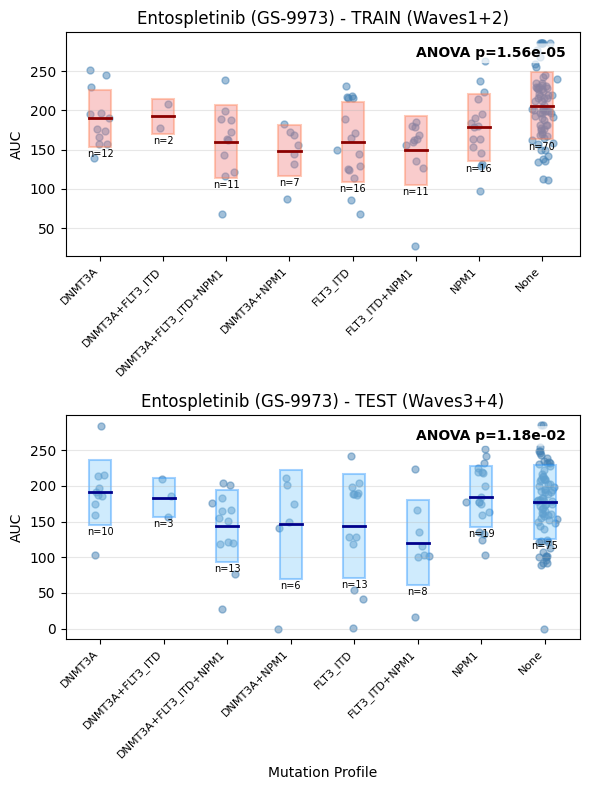

Drug:Ibrutinib (PCI-32765)


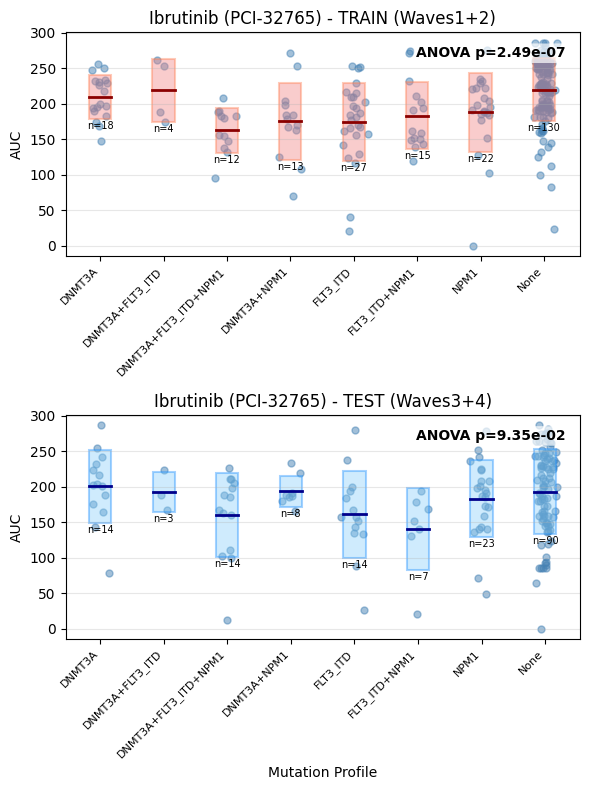

Drug:Midostaurin


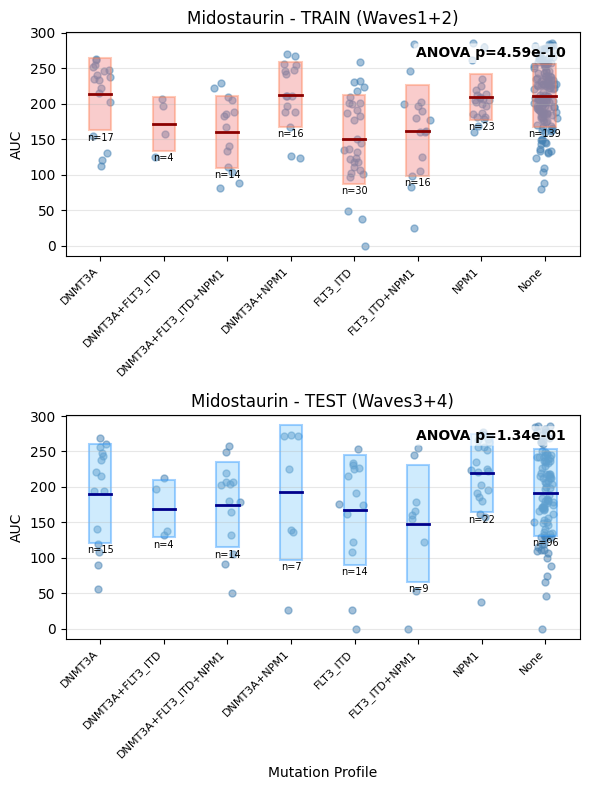

Drug:Selumetinib (AZD6244)


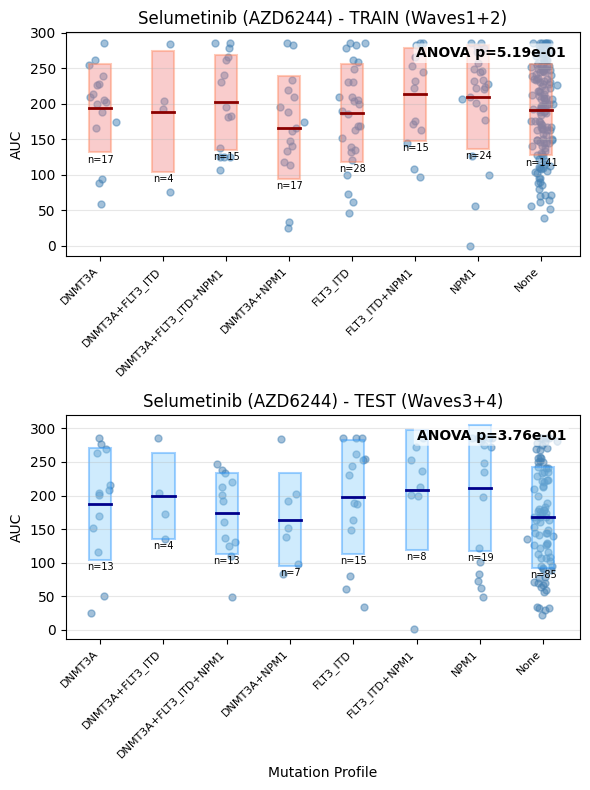

Drug:Trametinib (GSK1120212)


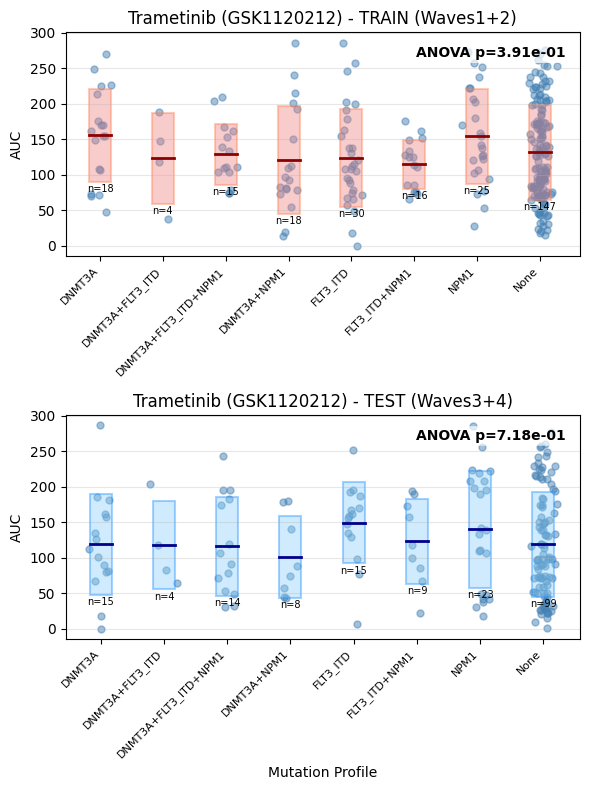

Drug:Venetoclax


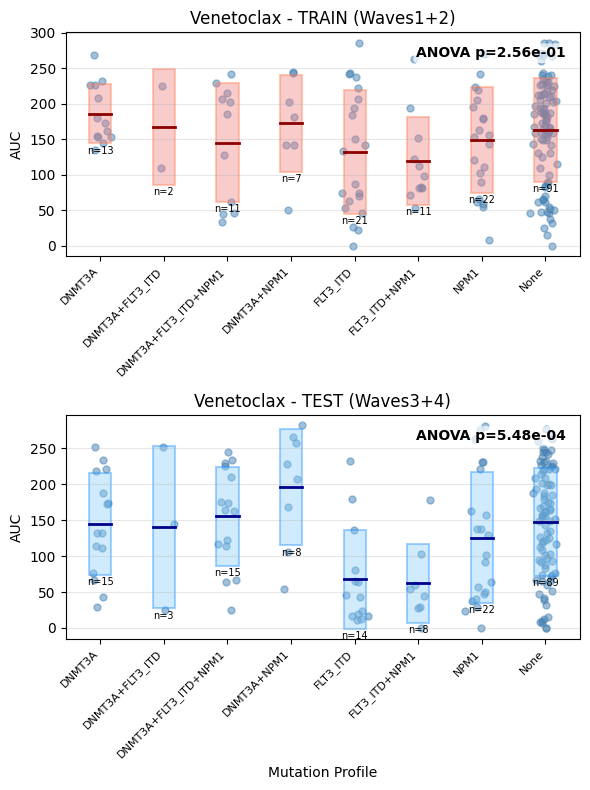

In [6]:
# AUC by mutation profile with mean ± s.d. boxes (Train vs Test)
AUC_by_mutation_profile(df, combined=False)

# Prepare for Optimization
## Create exp data

The 8 mutation profiles (FLT3-ITD, NPM1, DNMT3A and their combinations) for 3 drugs: Venetoclax, Ibrutinib, Entospletinib.

In [9]:
# mutation class
classification = pd.read_csv("inputs/Palma_class_extended.csv")
gene_to_class = dict(zip(classification['symbol'], classification['class']))
gene_to_class

{'AKT1': 'oncogene',
 'BCL2': 'oncogene',
 'CCND1': 'oncogene',
 'CDKN2A': 'TSG',
 'CEBPA': 'TSG',
 'DNMT3A': 'TSG',
 'ETV6': 'TSG',
 'FBXW7': 'TSG',
 'FLT3': 'oncogene',
 'GSK3B': 'oncogene',
 'HOXA9': 'oncogene',
 'MAPK1': 'oncogene',
 'MEIS1': 'oncogene',
 'MYC': 'oncogene',
 'NPM1': 'TSG',
 'SOX4': 'oncogene',
 'STAT5A': 'oncogene',
 'TP53': 'TSG',
 'ATM': 'TSG',
 'CDKN1B': 'TSG',
 'CYCS': 'TSG',
 'MTOR': 'oncogene',
 'NRAS': 'oncogene',
 'PIK3CA': 'oncogene',
 'ROS1': 'oncogene',
 'TET2': 'TSG',
 'RUNX1': 'TSG',
 'ASXL1': 'TSG',
 'IDH2': 'oncogene',
 'SRSF2': 'oncogene'}

In [20]:
create_experimental_data(
    df, 
    mutation_genes=['FLT3_ITD', 'NPM1', 'DNMT3A'],
    cohort='Waves1+2',
    inhibitors=['Venetoclax', 'Ibrutinib', 'Entospletinib', 'Selumetinib','Midostaurin'],
    output_file='inputs/BeatAML_AUC_5drugs_Waves1+2.csv'
)

\nGenerating data for 8 profiles × 5 drugs = 40 experiments
\nSaved 40 experiments to inputs/BeatAML_AUC_5drugs_Waves1+2.csv
\nSummary by drug:
               Total patients   Mean AUC±SD
drug                                       
Entospletinib             145  173.02±21.53
Ibrutinib                 241  191.57±21.89
Midostaurin               259  186.43±27.75
Selumetinib               261  194.18±14.77
Venetoclax                178  154.34±22.17


,Experiments,Stimuli,Stimuli_efficacy,Inhibitors,Inhibitors_efficacy,Measured_nodes,Measured_values,n_patients,std,drug,mutation_profile
0,1,,,BCL2,1,AUC,163.40,91,72.91,Venetoclax,No mutation
1,2,,,BTK,1,AUC,219.95,130,44.23,Ibrutinib,No mutation
2,3,,,SYK,1,AUC,205.72,70,42.86,Entospletinib,No mutation
3,4,,,"MAP2K1,MAP2K2","1,1",AUC,191.87,141,64.50,Selumetinib,No mutation
4,5,,,"FLT3,KIT","1,1",AUC,211.29,139,44.26,Midostaurin,No mutation
5,6,FLT3,1,BCL2,1,AUC,131.74,21,87.09,Venetoclax,FLT3_ITD
6,7,FLT3,1,BTK,1,AUC,174.50,27,55.41,Ibrutinib,FLT3_ITD
7,8,FLT3,1,SYK,1,AUC,160.19,16,50.94,Entospletinib,FLT3_ITD
8,9,FLT3,1,"MAP2K1,MAP2K2","1,1",AUC,186.67,28,69.03,Selumetinib,FLT3_ITD
9,10,FLT3,1,"FLT3,KIT","1,1",AUC,149.99,30,62.17,Midostaurin,FLT3_ITD


In [21]:
create_experimental_data(
    df, 
    mutation_genes=['FLT3_ITD', 'NPM1', 'DNMT3A'],
    cohort='Waves3+4',
    inhibitors=['Venetoclax', 'Ibrutinib', 'Entospletinib', 'Selumetinib','Midostaurin'],
    output_file='inputs/BeatAML_AUC_5drugs_Waves3+4.csv'
)

\nGenerating data for 8 profiles × 5 drugs = 40 experiments
\nSaved 40 experiments to inputs/BeatAML_AUC_5drugs_Waves3+4.csv
\nSummary by drug:
               Total patients   Mean AUC±SD
drug                                       
Entospletinib             147  161.29±26.05
Ibrutinib                 173  177.96±21.50
Midostaurin               181  181.76±21.54
Selumetinib               164  188.53±18.29
Venetoclax                174  130.05±45.02


,Experiments,Stimuli,Stimuli_efficacy,Inhibitors,Inhibitors_efficacy,Measured_nodes,Measured_values,n_patients,std,drug,mutation_profile
0,1,,,BCL2,1,AUC,148.01,89,75.42,Venetoclax,No mutation
1,2,,,BTK,1,AUC,192.85,90,59.80,Ibrutinib,No mutation
2,3,,,SYK,1,AUC,177.06,75,51.66,Entospletinib,No mutation
3,4,,,"MAP2K1,MAP2K2","1,1",AUC,167.49,85,75.62,Selumetinib,No mutation
4,5,,,"FLT3,KIT","1,1",AUC,192.00,96,60.77,Midostaurin,No mutation
5,6,FLT3,1,BCL2,1,AUC,67.68,14,68.71,Venetoclax,FLT3_ITD
6,7,FLT3,1,BTK,1,AUC,160.96,14,61.14,Ibrutinib,FLT3_ITD
7,8,FLT3,1,SYK,1,AUC,143.85,13,73.05,Entospletinib,FLT3_ITD
8,9,FLT3,1,"MAP2K1,MAP2K2","1,1",AUC,197.65,15,84.73,Selumetinib,FLT3_ITD
9,10,FLT3,1,"FLT3,KIT","1,1",AUC,167.51,14,78.10,Midostaurin,FLT3_ITD


## Extend PBN for drug targets
drug2target = {
    'Venetoclax': ['BCL2'],   
    'Ibrutinib': ['BTK'],   
    'Entospletinib': ['SYK'],  
    'Trametinib': ['MAP2K1','MAP2K2'],  
    'Selumetinib': ['MAP2K1','MAP2K2'],  
    'Midostaurin': ['FLT3','KIT'],  
    } 

In [11]:
# The Palma model
network = KGBN.load_network(network_file)
KGBN.vis_network(network, output_html="Palma2021_nophe.html", interactive=True, color_node='lightblue', physics=False)

No initial state provided, using a random initial state
Network loaded successfully. There are 18 genes in the network.
Network visualization saved to Palma2021_nophe.html


In [15]:
# extended PBN by adding drug targets
genes = list(network.nodeDict.keys())
genes = genes + ['BCL2','SYK', 'BTK','MAP2K1','MAP2K2','KIT']

# Extend to a PBN by adding 3 alternative networks
KG_OR_string, relations = KGBN.load_signor_network(genes, joiner='|')
KG_AND_string, relations = KGBN.load_signor_network(genes, joiner='&')
KG_IW_string, relations = KGBN.load_signor_network(genes, joiner='inhibitor_wins')

KG_OR = KGBN.load_network_from_string(KG_OR_string)
KG_AND = KGBN.load_network_from_string(KG_AND_string)
KG_IW = KGBN.load_network_from_string(KG_IW_string)

pbn_string = KGBN.merge_networks([network, KG_OR, KG_AND, KG_IW], method="PBN", prob=0.25)
pbn = KGBN.load_pbn_from_string(pbn_string)
print(pbn_string)

number of genes found: 24
[2322, 4869, 207, 596, 595, 1029, 1050, 1788, 5594, 2120, 55294, 2932, 3205, 4211, 4609, 6659, 6776, 7157, 596, 6850, 695, 5604, 5605, 3815]
number of genes found: 24
[2322, 4869, 207, 596, 595, 1029, 1050, 1788, 5594, 2120, 55294, 2932, 3205, 4211, 4609, 6659, 6776, 7157, 596, 6850, 695, 5604, 5605, 3815]
number of genes found: 24
[2322, 4869, 207, 596, 595, 1029, 1050, 1788, 5594, 2120, 55294, 2932, 3205, 4211, 4609, 6659, 6776, 7157, 596, 6850, 695, 5604, 5605, 3815]
No initial state provided, using a random initial state
Network loaded successfully. There are 24 genes in the network.
No initial state provided, using a random initial state
Network loaded successfully. There are 24 genes in the network.
No initial state provided, using a random initial state
Network loaded successfully. There are 24 genes in the network.
No initial state provided, using a random initial state
PBN loaded successfully. There are 24 genes in the network.
AKT1 = AKT1 & FLT3, 0.2

{('AKT1', 'AKT1'): 0.2, ('FLT3', 'AKT1'): 0.431, ('AKT1', 'MAPK1'): 0.532, ('MAPK1', 'MAPK1'): 0.2, ('MAP2K2', 'MAPK1'): 0.745, ('MAP2K1', 'MAPK1'): 0.75, ('AKT1', 'GSK3B'): 0.793, ('MAPK1', 'GSK3B'): 0.384, ('GSK3B', 'GSK3B'): 0.2, ('MAP2K1', 'GSK3B'): 0.344, ('MAPK1', 'TP53'): 0.777, ('GSK3B', 'TP53'): 0.727, ('HOXA9', 'MEIS1'): 0.62, ('DNMT3A', 'MEIS1'): 0.328, ('AKT1', 'CTNNB1'): 0.804, ('GSK3B', 'CTNNB1'): 0.86, ('FLT3', 'CTNNB1'): 0.409, ('KIT', 'CTNNB1'): 0.392, ('SOX4', 'CTNNB1'): 0.591, ('GSK3B', 'CCND1'): 0.783, ('CTNNB1', 'CCND1'): 0.8, ('MYC', 'CCND1'): 0.495, ('DNMT3A', 'CCND1'): 0.504, ('FLT3', 'FLT3'): 0.2, ('SYK', 'FLT3'): 0.408, ('AKT1', 'BTK'): 0.296, ('BTK', 'BTK'): 0.2, ('SYK', 'BTK'): 0.588, ('AKT1', 'FBXW7'): 0.41, ('NPM1', 'FBXW7'): 0.483, ('NPM1', 'HOXA9'): 0.351, ('DNMT3A', 'HOXA9'): 0.338, ('MAPK1', 'MYC'): 0.733, ('GSK3B', 'MYC'): 0.719, ('CTNNB1', 'MYC'): 0.744, ('FLT3', 'MYC'): 0.363, ('FBXW7', 'MYC'): 0.762, ('CEBPA', 'MYC'): 0.49, ('MYC', 'CDKN2A'): 0.765

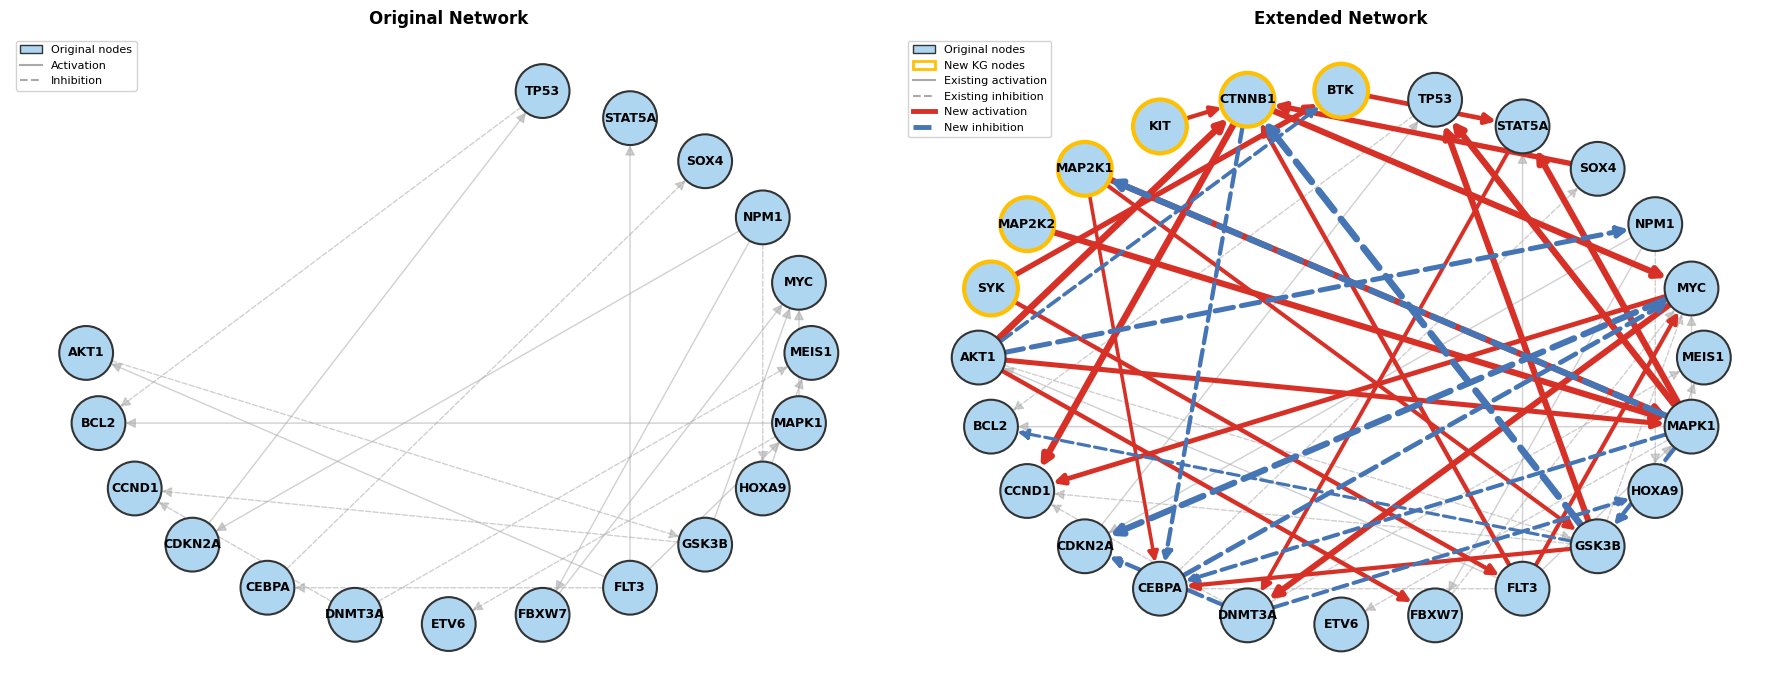

In [17]:
# Visualize the extended PBN
edge_scores = {(src, tgt): score
               for src, tgt, _, score in relations
               if score is not None}
print(edge_scores)
KGBN.vis_extension(network, pbn,
                   interactive=False,
                   layout='shell',
                   figsize=(18, 7),
                   color_node='#AED6F1',
                   extension_color_node='#AED6F1',
                   # node_groups=
                   # {'Drug targets': ({'BCL2', 'SYK','BTK'}, '#E1F2D0')},
                   edge_scores=edge_scores,
                   seed=1
                   )

In [16]:
# get phenotype score formula - reversed
formula = KGBN.phenotype_scores(
    genes=genes,
    simulation_results=None,
    phenotypes=['APOPTOSIS'],
    reversed=True
)
formula['APOPTOSIS']

Path found for 1 phenotypes: ['APOPTOSIS']


'AKT1 + BCL2 - CDKN2A - GSK3B + MAPK1 + MEIS1 + STAT5A - TP53'

## Config

In [34]:
# optimizer configuration used
config = {
    'de_params': {
        'strategy': 'best1bin',
        'maxiter': 3000,
        'popsize': 40,
        'tol': 0.001, 
        'atol': 0,
        'mutation': (0.5, 1.5),
        'recombination': 0.7,
        'seed': None,
        'disp': False,
        'init': 'sobol',
        'updating': 'deferred',
        'workers': -1,
        'early_stopping': False  # Control early stopping
    },
    'steady_state': {
        'method': 'tsmc',
            'tsmc_params': {
                'epsilon': 0.05, # range of transition probability [Default=0.001]
                'r': 0.1, # range of accuracy (most sensitive) [Default=0.025]
                's': 0.85, # probability to acquire defined accuracy [Default=0.95]
                'p_mir': 0.01, # perturbation in Miranda's & Parga's scheme [Default=0.001, 0.1%]
                'initial_nsteps': 100, # initial simulation steps [Recommended at 100 steps for n < 100]
                'max_iterations': 1000, # maximum convergence iterations [Default=5000]
                'freeze_constant': True # whether to treat self-loop as a fixed node
            },
    },
    'max_try': 2,  # Maximum number of attempts if optimization fails
    'success_threshold': 0.1, # threshold for accepting fit,
    'seed': 9
}

## Trainning
This has been done at UW Hyak.

# Figure 3: Extend to drug targets
## Plot optimization results

In [22]:
def expanded_plot_beataml(
    drug, 
    df, 
    drug2target, 
    text_size=7, 
    extended_gene=None, 
    use_spearman=False, 
    save_path=None, 
    train_cohort = 'Waves1+2', 
    test_cohort = 'Waves3+4',
    individual_drug=False
):
    """
    Expanded plot for BeatAML data with individual samples, colored by drug.
    Generates side-by-side plots for Waves1+2 (train) and Waves3+4 (test),
    or, if individual_drug=True, generates two rows (train and test) by five columns (drugs).
    
    Parameters:
    -----------
    drug : str
        Drug name or combined drugs (e.g., 'Venetoclax' or 'Ven+Ibr+Ent')
    df : DataFrame
        BeatAML data with columns: inhibitor, mutation_profile, auc, cohort
    drug2target : dict
        Mapping of drug names to their target genes
    text_size : int
        Font size for text annotations
    extended_gene : str
        Extended gene name (e.g., 'TP53')
    use_spearman : bool
        If True, use Spearman correlation; otherwise use Pearson
    save_path : str
        Path to save the figure (optional)
    individual_drug : bool
        If True, plot one subplot for each individual drug (2 rows x 5 columns)
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import re
    from scipy import stats
    from scipy.stats import spearmanr
    from adjustText import adjust_text
    
    # Color for highlighting points containing extended_gene in their label
    highlight_color = '#D783FF'
    box_height = 0.01
    np.random.seed(42)

    def normalize_profile_text(p):
        """Normalize mutation profile to consistent text format"""
        if isinstance(p, (set, frozenset, list, tuple)):
            genes = sorted(map(str, p))
        else:
            s = re.sub(r'[\{\}]', '', str(p))
            genes = sorted([g.strip() for g in s.split(',') if g.strip()])
        return "+".join(genes) if genes else "None"
    
    def minmax_normalize(series):
        min_val = series.min()
        max_val = series.max()
        if max_val - min_val == 0:
            return series * 0
        return (series - min_val) / (max_val - min_val)

    # File loading logic
    name = f'{drug}_{extended_gene}' if extended_gene else drug
        
    if extended_gene == 'NRAS':
        train_path = f'optimization_results/BeatAML_-AUC_{drug}_NRAS_DAB_{train_cohort}_AND+OR+IW/'
        train_results_df = pd.read_csv(f'{train_path}detailed_results.csv')
        test_results_df = pd.read_csv(f'{train_path}{test_cohort}/detailed_results.csv')
    else:
        train_path = f'optimization_results/BeatAML_-AUC_{name}_{train_cohort}_AND+OR+IW/'
        train_results_df = pd.read_csv(f'{train_path}detailed_results.csv')
        test_results_df = pd.read_csv(f'{train_path}{test_cohort}/detailed_results.csv')
    
    data_df_train = pd.read_csv(f'inputs/BeatAML_AUC_{name}_{train_cohort}.csv')
    data_df_test = pd.read_csv(f'inputs/BeatAML_AUC_{name}_{test_cohort}.csv')
    
    train_results_df['Predicted_Normalized'] = minmax_normalize(train_results_df['Predicted_Value'])
    test_results_df['Predicted_Normalized'] = minmax_normalize(test_results_df['Predicted_Value'])
    
    all_drug_targets = set()
    for targets in drug2target.values():
        all_drug_targets.update(targets)
    
    def get_profile_label_from_exp(row):
        mutated_genes = set()
        stimuli = str(row.get('Stimuli', ''))
        if stimuli and stimuli != 'nan':
            for gene in stimuli.split(','):
                gene = gene.strip()
                if gene:
                    if gene == 'FLT3': mutated_genes.add('FLT3_ITD')
                    else: mutated_genes.add(gene)
        inhibitors = str(row.get('Inhibitors', ''))
        if inhibitors and inhibitors != 'nan':
            for gene in inhibitors.split(','):
                gene = gene.strip()
                if gene and gene not in all_drug_targets:
                    mutated_genes.add(gene)
        return '+'.join(sorted(mutated_genes)) if mutated_genes else 'None'
    
    data_df_train['profile_label'] = data_df_train.apply(get_profile_label_from_exp, axis=1)
    data_df_test['profile_label'] = data_df_test.apply(get_profile_label_from_exp, axis=1)
    
    exp_to_drug_train = dict(zip(data_df_train['Experiments'], data_df_train['drug']))
    exp_to_drug_test = dict(zip(data_df_test['Experiments'], data_df_test['drug']))
    exp_to_profile_train = dict(zip(data_df_train['Experiments'], data_df_train['profile_label']))
    exp_to_profile_test = dict(zip(data_df_test['Experiments'], data_df_test['profile_label']))
    
    train_results_df['profile_label'] = train_results_df['Experiment_ID'].map(exp_to_profile_train)
    train_results_df['drug_name'] = train_results_df['Experiment_ID'].map(exp_to_drug_train)
    test_results_df['profile_label'] = test_results_df['Experiment_ID'].map(exp_to_profile_test)
    test_results_df['drug_name'] = test_results_df['Experiment_ID'].map(exp_to_drug_test)
    
    if drug == 'Ven+Ibr+Ent':
        drug_samples = df[df['inhibitor'].str.contains('Venetoclax|Ibrutinib|Entospletinib', case=False, na=False)].copy()
    elif drug == '5drugs':
        drug_samples = df[df['inhibitor'].str.contains('Venetoclax|Ibrutinib|Entospletinib|Midostaurin|Selumetinib', case=False, na=False)].copy()
    else:
        drug_samples = df[df['inhibitor'].str.contains(drug, case=False, na=False)].copy()
    
    drug_samples['profile_label'] = drug_samples['mutation_profile'].apply(normalize_profile_text)
    
    def get_drug_from_inhibitor(inhibitor):
        inhibitor_lower = str(inhibitor).lower()
        if 'venetoclax' in inhibitor_lower: return 'Venetoclax'
        elif 'ibrutinib' in inhibitor_lower: return 'Ibrutinib'
        elif 'entospletinib' in inhibitor_lower: return 'Entospletinib'
        elif 'trametinib' in inhibitor_lower: return 'Trametinib'
        elif 'selumetinib' in inhibitor_lower: return 'Selumetinib'
        elif 'midostaurin' in inhibitor_lower: return 'Midostaurin'
        return 'Unknown'
    
    drug_samples['Drug_name'] = drug_samples['inhibitor'].apply(get_drug_from_inhibitor)
    train_samples = drug_samples[drug_samples['cohort'] == train_cohort].copy()
    test_samples = drug_samples[drug_samples['cohort'] == test_cohort].copy()
    
    drug_colors = {
        'Venetoclax': '#D2B55B', 'Ibrutinib': '#377EB8', 'Entospletinib': '#4DAF4A',
        'Selumetinib': '#EAC6CB', 'Midostaurin': '#C0C0C0', 'Trametinib': '#E3AFC2'
    }
    drugs_plot_list = ['Venetoclax', 'Ibrutinib', 'Entospletinib', 'Midostaurin', 'Selumetinib']

    def plot_panel(ax, samples, results_df, drug_colors, cohort_name, is_train=True):
        results_df['profile_drug'] = results_df['profile_label'] + '_' + results_df['drug_name']
        pred_map_df = results_df[['profile_drug', 'Predicted_Normalized']].drop_duplicates(subset='profile_drug', keep='first')
        pred_map = dict(zip(pred_map_df['profile_drug'], pred_map_df['Predicted_Normalized']))
        
        samples = samples.copy()
        samples['profile_drug'] = samples['profile_label'] + '_' + samples['Drug_name']
        samples['predicted'] = samples['profile_drug'].map(pred_map)
        samples = samples.dropna(subset=['predicted', 'auc'])
        
        if len(samples) == 0: return None, None, None
        
        for _, row in samples.iterrows():
            y_jitter = row['predicted'] + np.random.normal(0, 0.012)
            color = drug_colors.get(row['Drug_name'], 'gray')
            ax.scatter(row['auc'], y_jitter, alpha=0.3, s=25, color=color, edgecolors='none')
        
        profile_drug_means = samples.groupby(['profile_label', 'Drug_name']).agg({
            'auc': ['mean', 'std'], 'predicted': 'first'
        }).reset_index()
        profile_drug_means.columns = ['profile_label', 'Drug_name', 'auc_mean', 'auc_std', 'predicted']
        
        if use_spearman:
            r, p_value = spearmanr(profile_drug_means['auc_mean'], profile_drug_means['predicted'])
            corr_label = 'Spearman'
        else:
            r, p_value = stats.pearsonr(profile_drug_means['auc_mean'], profile_drug_means['predicted'])
            corr_label = 'Pearson'
        
        if len(profile_drug_means) >= 2:
            slope, intercept, _, _, _ = stats.linregress(profile_drug_means['auc_mean'], profile_drug_means['predicted'])
            x_line = np.array([profile_drug_means['auc_mean'].min(), profile_drug_means['auc_mean'].max()])
            ax.plot(x_line, slope * x_line + intercept, color='gray', lw=1.5, ls='--', alpha=0.6)
        
        patch_texts = []
        for _, row in profile_drug_means.iterrows():
            mean_val, std_val, pred = row['auc_mean'], row['auc_std'], row['predicted']
            if pd.isna(std_val): std_val = 0
            base_color = drug_colors.get(row['Drug_name'], 'gray')
            
            # Highlighting logic: Keep drug color filling, add purple border
            is_highlighted = extended_gene is not None and extended_gene in row['profile_label'].split('+')
            if is_highlighted:
                edge_c = highlight_color
                l_width = 1.5  # Thicker border for visibility
            else:
                edge_c = 'black'
                l_width = 1.0

            ax.add_patch(plt.Rectangle((mean_val - std_val, pred - box_height/2), 
                                        2*std_val, box_height, 
                                        facecolor=base_color, alpha=0.3, edgecolor=base_color))
            
            ax.plot([mean_val, mean_val], [pred - box_height/2, pred + box_height/2], 
                    color='darkred' if is_train else 'darkblue', lw=2, zorder=10)
            
            # Scatter using drug color for filling
            ax.scatter(mean_val, pred, s=100, color=base_color, edgecolor=edge_c, linewidth=l_width, zorder=15)
            
            txt = ax.text(mean_val, pred, f'{row["profile_label"]}', fontsize=text_size, alpha=0.9)
            patch_texts.append(txt)
        
        
        adjust_text(patch_texts, ax=ax, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))
        ax.set_xlabel('Experimental Value (AUC)')
        ax.set_ylabel('Predicted Value (reversed Apoptosis Score)')
        ax.set_title(f"{'TRAIN' if is_train else 'TEST'} (BeatAML {cohort_name})\n({corr_label} r={r:.3f}, p={p_value:.3e})", fontweight='bold')
        ax.grid(True, alpha=0.2)
        return r, p_value, corr_label

    def get_custom_legend(current_drugs):
        handles = [plt.Line2D([], [], color=drug_colors[d], marker='o', ls='', label=d, markeredgecolor='black') for d in current_drugs if d in drug_colors]
        if extended_gene:
            # Legend handle for highlight: neutral gray fill with the purple highlight border
            hl_handle = plt.Line2D([], [], marker='o', color='#FFFFFF', markeredgecolor=highlight_color, 
                                   markeredgewidth=1.5, ls='', label=f'Contains {extended_gene}')
            handles.append(hl_handle)
        return handles

    if not individual_drug:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
        plot_panel(ax1, train_samples, train_results_df, drug_colors, train_cohort, True)
        plot_panel(ax2, test_samples, test_results_df, drug_colors, test_cohort, False)
        
        used_drugs = sorted(list(drug_samples['Drug_name'].unique()))
        ax2.legend(handles=get_custom_legend(used_drugs), loc='upper left', bbox_to_anchor=(1.02, 1), title="Legend")
    else:
        fig, axs = plt.subplots(2, 5, figsize=(21, 9), sharex=True, sharey=True)
        for idx, drug_name in enumerate(drugs_plot_list):
            tr_s = train_samples[train_samples['Drug_name'] == drug_name]
            r, p_value, corr_label = plot_panel(axs[0, idx], tr_s, train_results_df, drug_colors, train_cohort, True)
            axs[0, idx].set_title(f"TRAIN: {drug_name}\n({corr_label} r={r:.3f}, p={p_value:.1e})" if r is not None else f"TRAIN: {drug_name}\n(no data)", 
                     color='black', fontweight='bold')
            
            te_s = test_samples[test_samples['Drug_name'] == drug_name]
            r, p_value, corr_label = plot_panel(axs[1, idx], te_s, test_results_df, drug_colors, test_cohort, False)
            axs[1, idx].set_title(f"TEST: {drug_name}\n({corr_label} r={r:.3f}, p={p_value:.1e})" if r is not None else f"TEST: {drug_name}\n(no data)", 
                     color='black', fontweight='bold')

        axs[0, -1].legend(handles=get_custom_legend(drugs_plot_list), loc='upper left', bbox_to_anchor=(1.05, 1))
        fig.suptitle(f"BeatAML Analysis: {drug}", fontsize=16, y=1.02)

    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

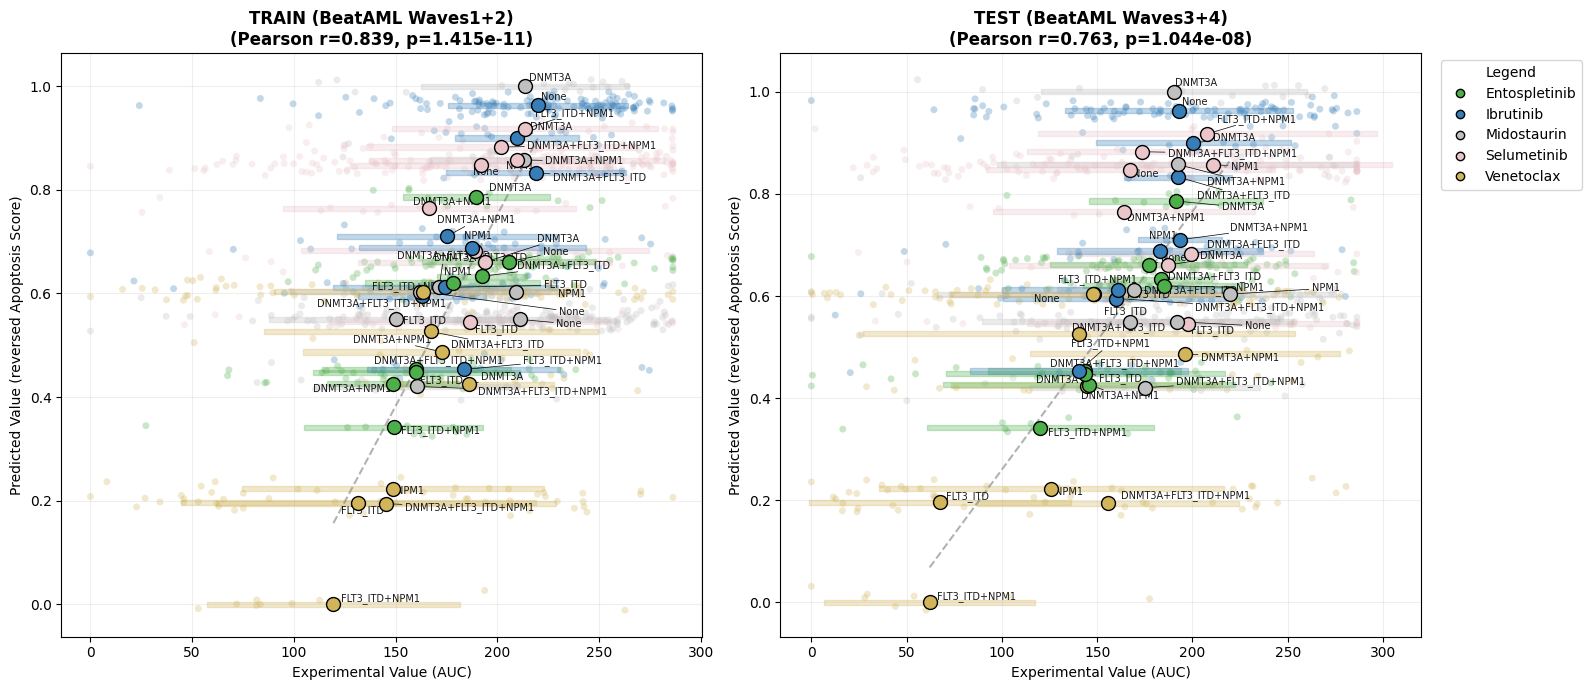

In [23]:
expanded_plot_beataml(
    drug='5drugs', 
    df=df, 
    drug2target=drug2target, 
    use_spearman=False,
    save_path='optimization_results/BeatAML_-AUC_5drugs_Waves1+2_AND+OR+IW/prediction_vs_experimental_individual.png'
)

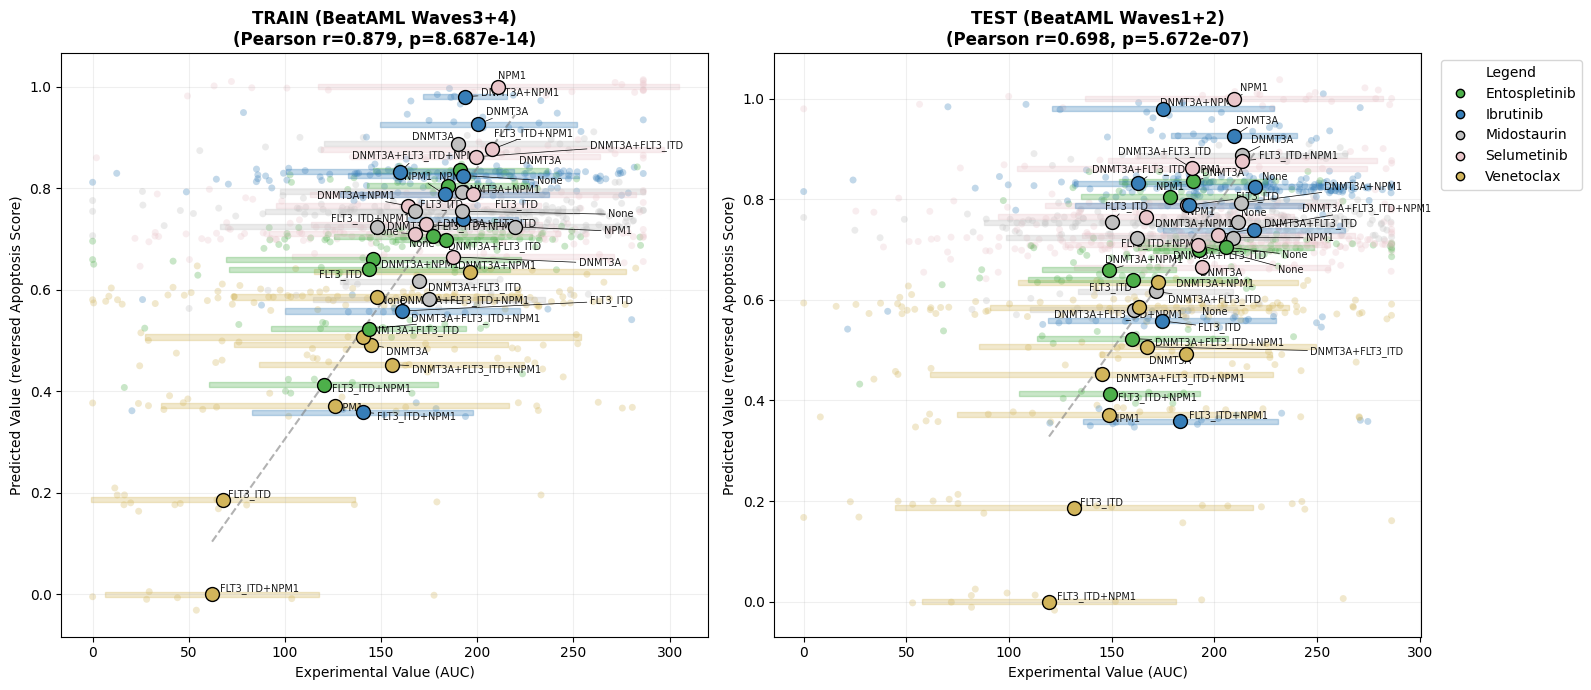

In [24]:
# Cross-cohort validation
expanded_plot_beataml(
    drug='5drugs', 
    df=df, 
    drug2target=drug2target, 
    use_spearman=False,
    save_path='optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/prediction_vs_experimental_individual.png',
    train_cohort = 'Waves3+4',
    test_cohort = 'Waves1+2'
)

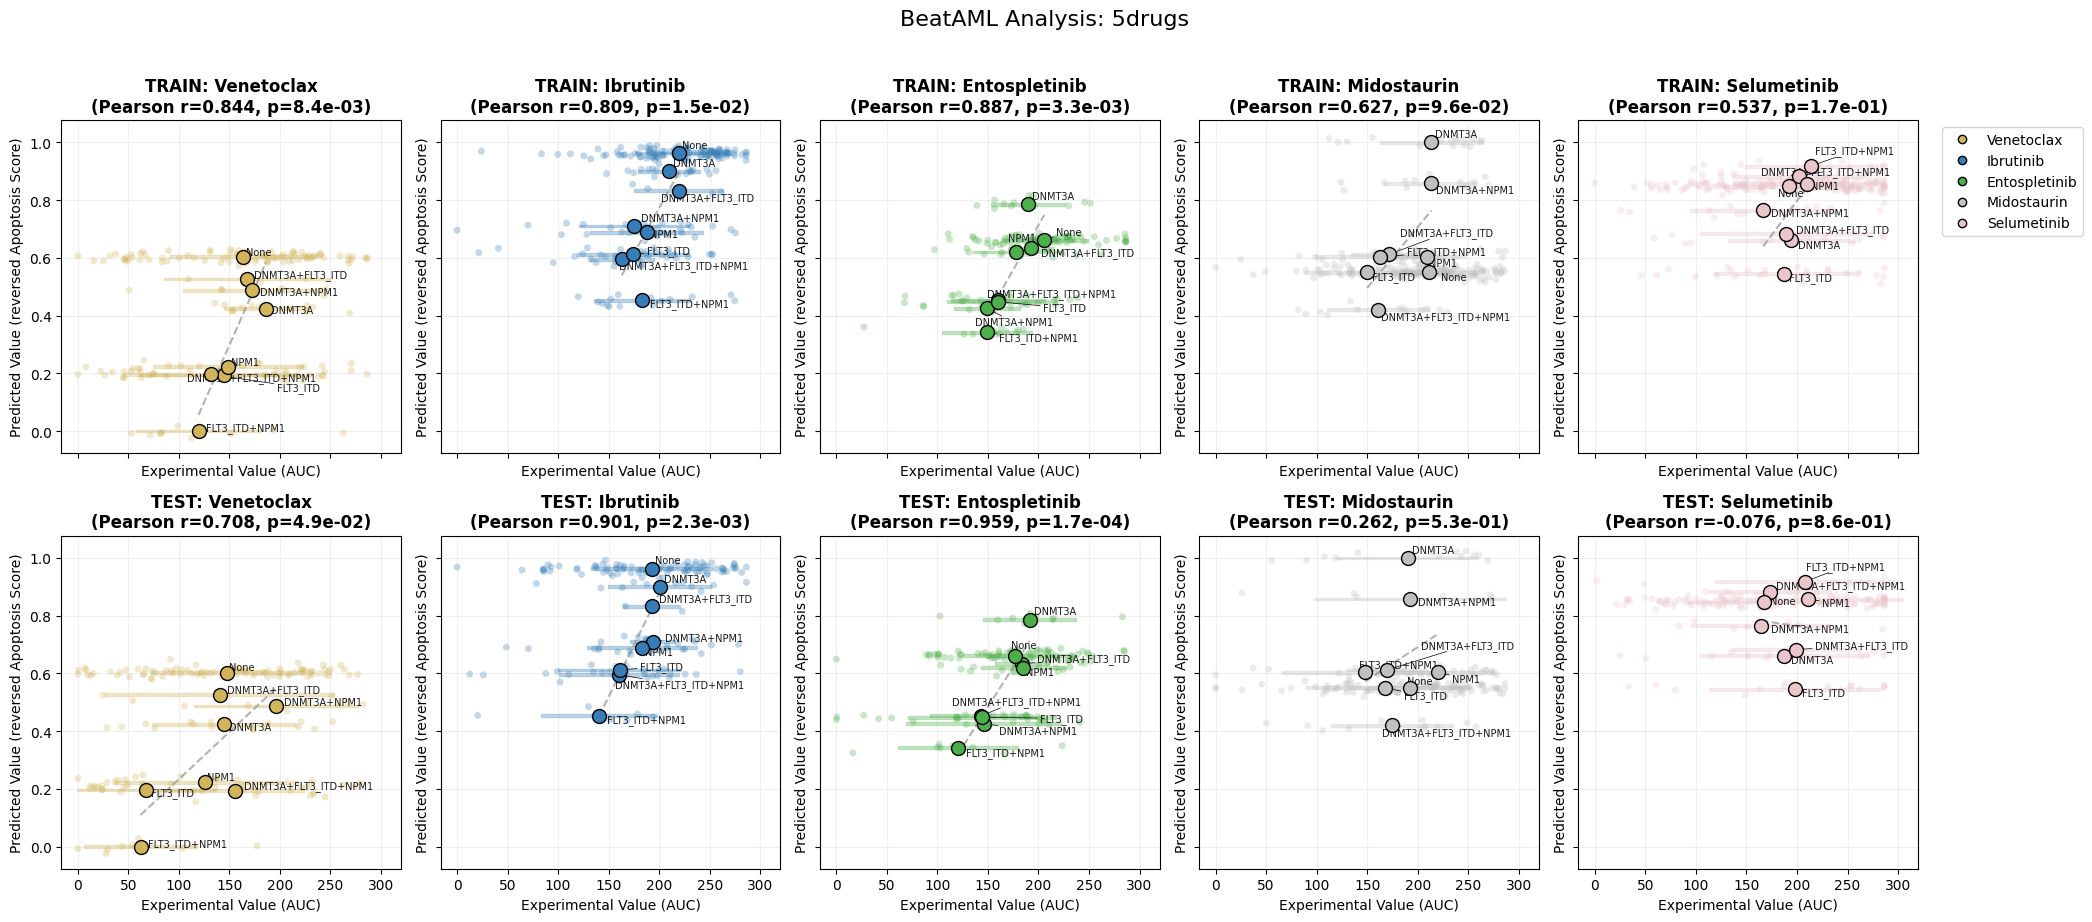

In [25]:
# plot individual drugs
expanded_plot_beataml(
    drug='5drugs', 
    df=df, 
    drug2target=drug2target, 
    use_spearman=False,
    save_path='optimization_results/BeatAML_-AUC_5drugs_Waves1+2_AND+OR+IW/prediction_vs_experimental_individual_drugs.png',
    individual_drug=True
)

## LOCO: leave one combination of mutation out

In [26]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

def _infer_left_out_condition(fold_dir, mode=None):
    """
    Infer the left-out condition from test_data.csv.
    For LOCO: uses mutation_profile
    For LODO: uses drug
    If mode is None, infer from prefix/fallback columns.
    """
    test_data_csv = os.path.join(fold_dir, "test_data.csv")
    if not os.path.exists(test_data_csv):
        return os.path.basename(fold_dir)

    df = pd.read_csv(test_data_csv)

    if df.empty:
        return os.path.basename(fold_dir)

    # Explicit mode if provided
    if mode == "LOCO" and "mutation_profile" in df.columns:
        vals = df["mutation_profile"].dropna().astype(str).str.replace('DAB2IP', 'NRAS').unique()
    elif mode == "LODO" and "drug" in df.columns:
        vals = df["drug"].dropna().astype(str).unique()
    else:
        # Fallback inference
        if "mutation_profile" in df.columns and df["mutation_profile"].nunique(dropna=True) == 1:
            vals = df["mutation_profile"].dropna().astype(str).str.replace('DAB2IP', 'NRAS').unique()
        elif "drug" in df.columns and df["drug"].nunique(dropna=True) == 1:
            vals = df["drug"].dropna().astype(str).unique()
        else:
            return os.path.basename(fold_dir)

    if len(vals) == 0:
        return os.path.basename(fold_dir)
    elif len(vals) == 1:
        return vals[0]
    else:
        return " | ".join(sorted(vals))


def _minmax(x):
    x = np.asarray(x, dtype=float)
    xmin = np.min(x)
    xmax = np.max(x)
    if xmax == xmin:
        return np.zeros_like(x, dtype=float)
    return (x - xmin) / (xmax - xmin)


def _format_p(p):
    if pd.isna(p):
        return np.nan
    return f"{p:.0e}"


def _calc_metrics(df):
    if df is None or df.empty:
        return {
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "n_exp": 0,
        }

    y_true = _minmax(df["Measured_Value"].to_numpy())
    y_pred = _minmax(df["Predicted_Value"].to_numpy())

    out = {
        "n_exp": len(df),
        "mae": np.mean(np.abs(y_pred - y_true)),
        "rmse": np.sqrt(np.mean((y_pred - y_true) ** 2)),
    }

    if len(df) >= 2 and pd.Series(y_true).nunique() > 1 and pd.Series(y_pred).nunique() > 1:
        pr, pp = pearsonr(y_pred, y_true)
        out.update({
            "pearson_r": pr,
            "pearson_p": pp,
        })
    else:
        out.update({
            "pearson_r": np.nan,
            "pearson_p": np.nan,
        })

    return out


def generate_cv_summary_table(
    base_dir,
    prefix="BeatAML_AUC_5drugs_LOCO",
    meta_csv="inputs/BeatAML_AUC_5drugs.csv",
    mode=None,
    save_path=None,
):
    """
    Build a complete CV summary table.

    Metrics are computed after min-max normalization of Measured_Value and
    Predicted_Value within each train/test result file.

    For LOCO: one row per held-out mutation_profile
    For LODO: one row per held-out drug
    """

    if mode is None:
        mode = "LODO" if "LODO" in prefix.upper() else "LOCO"

    fold_dirs = sorted(glob.glob(os.path.join(base_dir, f"{prefix}_fold_*")))
    if not fold_dirs:
        raise FileNotFoundError(
            f"No directories found matching {os.path.join(base_dir, prefix + '_fold_*')}"
        )

    meta = pd.read_csv(meta_csv)
    key_col = "mutation_profile" if mode == "LOCO" else "drug"

    meta_summary = (
        meta.groupby(key_col)
        .agg(
            n_patients_mean=("n_patients", "mean"),
            n_patients_min=("n_patients", "min"),
            n_patients_max=("n_patients", "max"),
            std_mean=("std", "mean"),
            std_min=("std", "min"),
            std_max=("std", "max"),
            n_drugs=("drug", "nunique"),
        )
        .reset_index()
    )

    if mode == "LOCO":
        drug_detail = (
            meta.assign(
                detail=lambda d: d["drug"].astype(str)
                + " (n="
                + d["n_patients"].astype(str)
                + ", sd="
                + d["std"].round(2).astype(str)
                + ")"
            )
            .groupby("mutation_profile")["detail"]
            .apply(lambda x: "; ".join(x))
            .reset_index(name="drug_level_detail")
        )
        meta_summary = meta_summary.merge(drug_detail, on="mutation_profile", how="left")
        meta_summary['mutation_profile'] = meta_summary['mutation_profile'].str.replace('DAB2IP', 'NRAS')

    rows = []
    for fold_dir in fold_dirs:
        left_out = _infer_left_out_condition(fold_dir, mode=mode)

        train_csv = os.path.join(fold_dir, "detailed_results.csv")
        test_csv = os.path.join(fold_dir, "Test_Evaluation", "detailed_results.csv")

        df_train = pd.read_csv(train_csv) if os.path.exists(train_csv) else pd.DataFrame()
        df_test = pd.read_csv(test_csv) if os.path.exists(test_csv) else pd.DataFrame()

        train_metrics = _calc_metrics(df_train)
        test_metrics = _calc_metrics(df_test)

        rows.append({
            key_col: left_out,
            "train_n_exp": train_metrics["n_exp"],
            "train_pearson_r": train_metrics["pearson_r"],
            "train_pearson_p": train_metrics["pearson_p"],
            "train_mae": train_metrics["mae"],
            "train_rmse": train_metrics["rmse"],
            "test_n_exp": test_metrics["n_exp"],
            "test_pearson_r": test_metrics["pearson_r"],
            "test_pearson_p": test_metrics["pearson_p"],
            "test_mae": test_metrics["mae"],
            "test_rmse": test_metrics["rmse"],
        })
    summary = pd.DataFrame(rows).merge(meta_summary, on=key_col, how="left")
    summary = summary.sort_values("test_pearson_r", ascending=False)

    # round numeric columns except p-values
    numeric_cols = summary.select_dtypes(include=np.number).columns.tolist()
    pval_cols = ["train_pearson_p", "test_pearson_p"]
    round_cols = [c for c in numeric_cols if c not in pval_cols]
    summary[round_cols] = summary[round_cols].round(3)

    # format p-values as scientific notation strings
    for col in pval_cols:
        summary[col] = summary[col].apply(_format_p)

    if save_path is not None:
        summary.to_csv(save_path, index=False)

    return summary

summary_loco = generate_cv_summary_table(
    base_dir="optimization_results/",
    prefix="BeatAML_AUC_5drugs_LOCO",
    meta_csv="inputs/BeatAML_AUC_5drugs.csv",
    mode="LOCO",
    save_path="outputs/BeatAML_AUC_5drugs_LOCO_summary.csv",
)

summary_loco

,mutation_profile,train_n_exp,train_pearson_r,train_pearson_p,train_mae,train_rmse,test_n_exp,test_pearson_r,test_pearson_p,test_mae,test_rmse,n_patients_mean,n_patients_min,n_patients_max,std_mean,std_min,std_max,n_drugs,drug_level_detail
0,DNMT3A,35,0.862,3e-11,0.095,0.122,5,0.957,1e-02,0.081,0.113,28.8,22,32,54.824,39.74,71.12,5,"Venetoclax (n=28, sd=62.12); Ibrutinib (n=32, ..."
5,"FLT3_ITD,NPM1",35,0.834,5e-10,0.096,0.126,5,0.723,2e-01,0.192,0.250,21.6,19,25,62.398,51.73,72.49,5,"Venetoclax (n=19, sd=64.62); Ibrutinib (n=22, ..."
6,NPM1,35,0.881,3e-12,0.083,0.112,5,0.710,2e-01,0.221,0.280,42.4,35,45,61.124,42.07,82.65,5,"Venetoclax (n=44, sd=82.65); Ibrutinib (n=45, ..."
4,FLT3_ITD,35,0.879,4e-12,0.081,0.109,5,0.616,3e-01,0.209,0.293,38.4,29,44,68.970,57.04,85.32,5,"Venetoclax (n=35, sd=85.32); Ibrutinib (n=41, ..."
1,"DNMT3A,FLT3_ITD",35,0.887,1e-12,0.079,0.113,5,0.437,5e-01,0.312,0.379,6.6,5,8,51.644,22.41,91.16,5,"Venetoclax (n=5, sd=91.16); Ibrutinib (n=7, sd..."
2,"DNMT3A,FLT3_ITD,NPM1",35,0.886,1e-12,0.086,0.114,5,0.341,6e-01,0.358,0.432,26.4,24,28,57.828,47.61,73.91,5,"Venetoclax (n=26, sd=73.91); Ibrutinib (n=26, ..."
3,"DNMT3A,NPM1",35,0.899,2e-13,0.080,0.107,5,0.111,9e-01,0.381,0.458,19.2,13,24,61.168,44.74,73.77,5,"Venetoclax (n=15, sd=73.77); Ibrutinib (n=21, ..."
7,No mutation,35,0.870,1e-11,0.096,0.117,5,-0.093,9e-01,0.529,0.541,201.2,145,235,59.766,49.58,74.36,5,"Venetoclax (n=180, sd=74.36); Ibrutinib (n=220..."


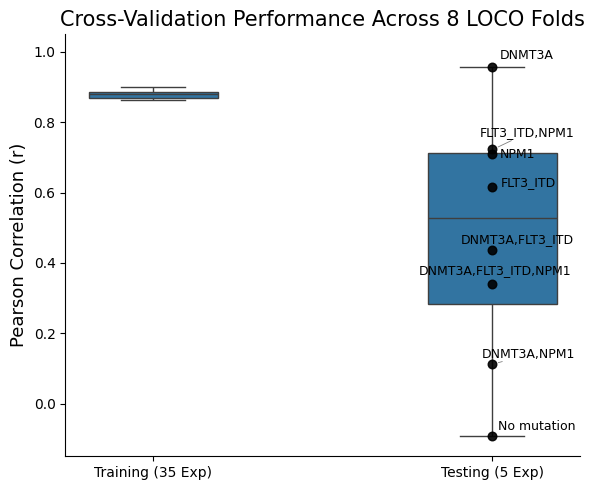

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from adjustText import adjust_text

def plot_cv_performance(base_dir, prefix='BeatAML_AUC_5drugs_LOCO', mode=None):
    fold_dirs = sorted(glob.glob(os.path.join(base_dir, f"{prefix}_fold_*")))
    if not fold_dirs:
        print(f"No directories found matching {os.path.join(base_dir, prefix + '_fold_*')}")
        return

    if mode is None:
        mode = "LODO" if "LODO" in prefix.upper() else "LOCO"

    rows = []
    for fold_dir in fold_dirs:
        left_out = _infer_left_out_condition(fold_dir, mode=mode)

        train_csv = os.path.join(fold_dir, "detailed_results.csv")
        if os.path.exists(train_csv):
            df_train = pd.read_csv(train_csv)
            if len(df_train) > 1:
                corr, _ = pearsonr(df_train['Predicted_Value'], df_train['Measured_Value'])
                rows.append({
                    "Correlation": corr,
                    "Cohort": "Training (35 Exp)",
                    "Condition": left_out
                })

        test_csv = os.path.join(fold_dir, "Test_Evaluation", "detailed_results.csv")
        if os.path.exists(test_csv):
            df_test = pd.read_csv(test_csv)
            if len(df_test) > 1:
                corr, _ = pearsonr(df_test['Predicted_Value'], df_test['Measured_Value'])
                rows.append({
                    "Correlation": corr,
                    "Cohort": "Testing (5 Exp)",
                    "Condition": left_out
                })

    plot_data = pd.DataFrame(rows)
    if plot_data.empty:
        print("No valid train/test correlations found.")
        return

    plt.figure(figsize=(6, 5))
    ax = sns.boxplot(
        x='Cohort',
        y='Correlation',
        data=plot_data,
        width=0.38,
        showfliers=False
    )

    texts = []
    cohort_order = ["Training (35 Exp)", "Testing (5 Exp)"]

    for i, cohort in enumerate(cohort_order):
        if cohort != "Testing (5 Exp)":
            continue
        sub = plot_data[plot_data["Cohort"] == cohort].copy().reset_index(drop=True)
        if sub.empty:
            continue

        xs = np.full(len(sub), i)
        ys = sub["Correlation"].values

        ax.scatter(xs, ys, s=38, alpha=0.9, color="black", zorder=3)

        for x, y, label in zip(xs, ys, sub["Condition"]):
            texts.append(
                ax.text(
                    x + 0.01, y + 0.003, str(label),
                    fontsize=9, ha='left', va='bottom'
                )
            )

    adjust_text(
        texts,
        ax=ax,
        only_move={'points': 'y', 'texts': 'y'},
        arrowprops=dict(arrowstyle='-', lw=0.6, color='gray')
    )

    n_folds = plot_data[plot_data["Cohort"] == "Testing (5 Exp)"].shape[0]
    title_mode = "LODO" if mode == "LODO" else "LOCO"
    ax.set_title(f'Cross-Validation Performance Across {n_folds} {title_mode} Folds', fontsize=15)
    ax.set_ylabel('Pearson Correlation (r)', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylim(min(-0.15, plot_data["Correlation"].min() - 0.05), 1.05)
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_cv_performance(
    base_dir='optimization_results/',
    prefix='BeatAML_AUC_5drugs_LOCO',
    mode='LOCO'
)

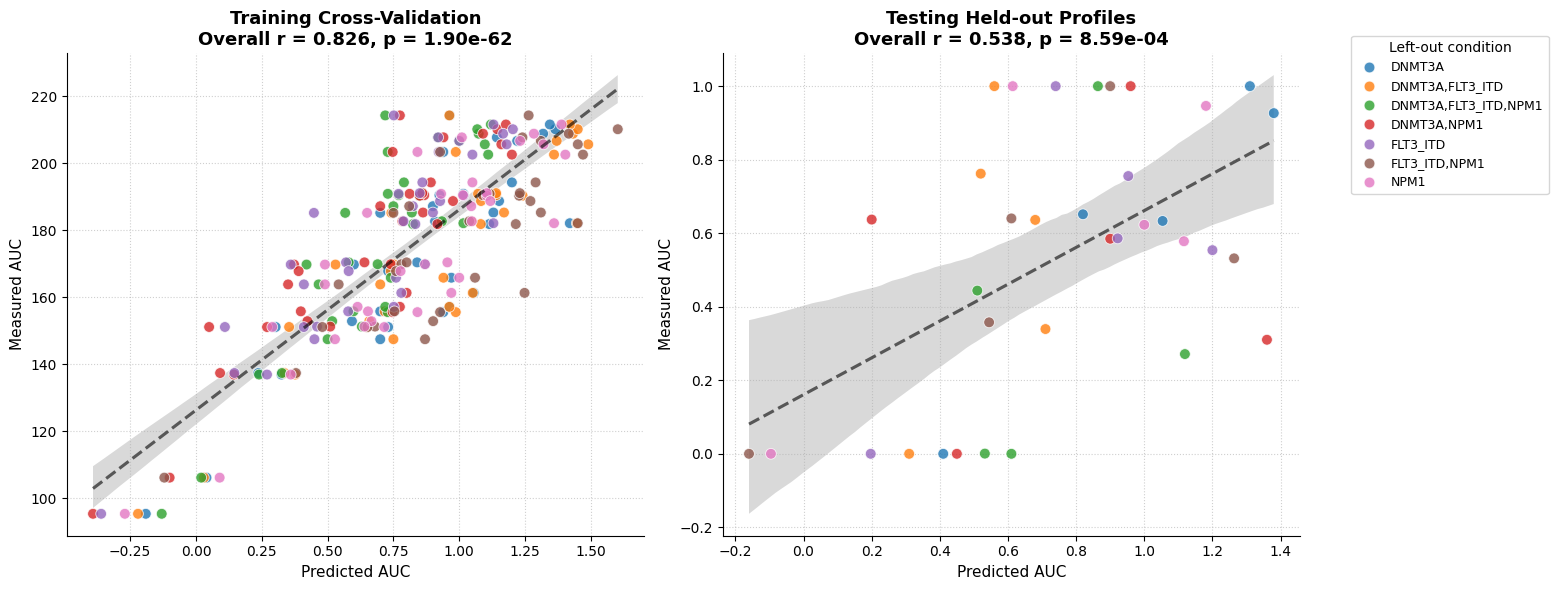

In [ ]:
def plot_cv_scatter(
    base_dir,
    prefix='BeatAML_AUC_5drugs_LOCO',
    mode=None,
    combined=False,
    exclude=None
):
    """
    Generates two scatter plots (Train and Test) plotting individual data points from all folds.

    If combined=False:
        - Plots are colored by actual left-out condition (mutation_profile or drug) and
          Pearson r is per-condition in annotation.

    If combined=True:
        - Plots are colored by fold, and the Pearson r reported is overall (across all data).

    Args:
        base_dir: directory containing result folds
        prefix: prefix for fold dirs, e.g. 'BeatAML_AUC_5drugs_LOCO'
        mode:   'LOCO' or 'LODO'; if None will infer from prefix (if combined is False)
        combined: (bool) Whether to color by fold and show overall Pearson r (combined=True),
                          or by left-out condition and condition-based r (combined=False)
        exclude: list of integers for folds to exclude, e.g. [0,1]
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import pearsonr
    import glob
    import os
    import re

    # Helper to extract the fold number
    def get_fold_num(fold_dir):
        m = re.search(r'_fold_(\d+)$', fold_dir)
        if m:
            return int(m.group(1))
        return None

    fold_dirs_all = sorted(glob.glob(os.path.join(base_dir, f"{prefix}_fold_*")))
    fold_dirs = []
    # Only include non-excluded folds
    for fd in fold_dirs_all:
        fold_num = get_fold_num(fd)
        if exclude is None:
            fold_dirs.append(fd)
        elif fold_num is not None and fold_num not in exclude:
            fold_dirs.append(fd)
    if not fold_dirs:
        print(f"No directories found matching {os.path.join(base_dir, prefix + '_fold_*')} after applying exclusion {exclude}")
        return

    def _minmax(x):
        x = np.asarray(x, dtype=float)
        xmin = np.min(x)
        xmax = np.max(x)
        if xmax == xmin:
            return np.zeros_like(x, dtype=float)
        return (x - xmin) / (xmax - xmin)

    if not combined:
        # color by left out condition
        if mode is None:
            mode = "LODO" if "LODO" in prefix.upper() else "LOCO"

        train_dfs = []
        test_dfs = []
        for fold_dir in fold_dirs:
            left_out = _infer_left_out_condition(fold_dir, mode=mode)
            train_csv = os.path.join(fold_dir, "detailed_results.csv")
            if os.path.exists(train_csv):
                df_train = pd.read_csv(train_csv).copy()
                df_train["Predicted_Value_Norm"] = _minmax(df_train["Predicted_Value"].to_numpy())
                df_train["Condition"] = left_out
                train_dfs.append(df_train)

            test_csv = os.path.join(fold_dir, "Test_Evaluation", "detailed_results.csv")
            if os.path.exists(test_csv):
                df_test = pd.read_csv(test_csv).copy()
                df_test["Predicted_Value_Norm"] = _minmax(df_test["Predicted_Value"].to_numpy())
                df_test["Condition"] = left_out
                test_dfs.append(df_test)

        df_train_all = pd.concat(train_dfs, ignore_index=True) if train_dfs else pd.DataFrame()
        df_test_all = pd.concat(test_dfs, ignore_index=True) if test_dfs else pd.DataFrame()

        # Consistent palette for only included, shown conditions
        all_conditions = sorted(
            set(df_train_all.get("Condition", pd.Series(dtype=str)).dropna().unique())
            .union(set(df_test_all.get("Condition", pd.Series(dtype=str)).dropna().unique()))
        )
        palette = dict(zip(all_conditions, sns.color_palette("tab10", n_colors=len(all_conditions))))

        def _condition_corr_text(df):
            lines = []
            for cond, sub in df.groupby("Condition"):
                if (
                    len(sub) >= 2
                    and sub["Predicted_Value_Norm"].nunique() > 1
                    and sub["Measured_Value"].nunique() > 1
                ):
                    r, p = pearsonr(sub["Predicted_Value_Norm"], sub["Measured_Value"])
                    lines.append(f"{cond}: r={r:.3f}, p={p:.2e}")
                else:
                    lines.append(f"{cond}: r=NA")
            return "\n".join(lines)

        def plot_cohort(df, title, ax, show_legend=False):
            if df.empty:
                ax.set_title(f"{title}\nNo data")
                return None, None

            scatter = sns.scatterplot(
                data=df,
                x="Measured_Value",
                y="Predicted_Value_Norm",
                hue="Condition",
                palette=palette,
                alpha=0.8,
                edgecolor="w",
                s=60,
                ax=ax,
                legend=show_legend,
                zorder=2
            )
            # Regression line and stats
            sns.regplot(
                data=df,
                x="Measured_Value",
                y="Predicted_Value_Norm",
                scatter=False,
                color="black",
                line_kws={'linestyle': '--', 'alpha': 0.5},
                ax=ax
            )

            corr_text = _condition_corr_text(df)
            ax.set_title(title, fontsize=13, weight='bold')
            ax.set_xlabel('Experimental Value (AUC)', fontsize=11)
            ax.set_ylabel('Predicted Value (Apoptosis Score)', fontsize=11)
            ax.grid(True, linestyle=':', alpha=0.6)
            ax.set_ylim(-0.05, 1.05)
            ax.text(
                0.02, 0.98,
                corr_text,
                transform=ax.transAxes,
                ha='left',
                va='top',
                fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
            )

            handles, labels = None, None
            if show_legend and ax.get_legend() is not None:
                handles, labels = ax.get_legend_handles_labels()
                ax.get_legend().remove()
                return handles, labels

            return None, None

        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        handles, labels = plot_cohort(df_train_all, 'Training Cross-Validation', axes[0], show_legend=True)
        plot_cohort(df_test_all, 'Testing Held-out Conditions', axes[1], show_legend=False)

        if handles and labels:
            fig.legend(
                handles, labels,
                title='Left-out condition',
                bbox_to_anchor=(0.9, 0.8),
                loc='center left',
                fontsize=9
            )
        sns.despine()
        plt.tight_layout(rect=[0, 0, 0.88, 1])
        plt.show()

    else:
        # combined mode: color by fold, Pearson r is overall
        train_dfs = []
        test_dfs = []
        fold_to_label = {}

        effective_mode = mode
        if effective_mode is None:
            effective_mode = "LODO" if "LODO" in prefix.upper() else "LOCO"

        for fold_dir in fold_dirs:
            fold_num = fold_dir.split('_fold_')[-1]
            left_out = _infer_left_out_condition(fold_dir, mode=effective_mode)
            label = left_out
            fold_to_label[fold_num] = label

            train_csv = os.path.join(fold_dir, "detailed_results.csv")
            if os.path.exists(train_csv):
                df_train = pd.read_csv(train_csv).copy()
                df_train['Fold'] = fold_num
                df_train['Fold_Label'] = label
                train_dfs.append(df_train)

            test_csv = os.path.join(fold_dir, "Test_Evaluation", "detailed_results.csv")
            if os.path.exists(test_csv):
                df_test = pd.read_csv(test_csv).copy()
                df_test['Fold'] = fold_num
                df_test['Fold_Label'] = label
                test_dfs.append(df_test)

        df_train_all = pd.concat(train_dfs, ignore_index=True) if train_dfs else pd.DataFrame()
        df_test_all = pd.concat(test_dfs, ignore_index=True) if test_dfs else pd.DataFrame()

        all_labels = sorted(
            set(df_train_all.get("Fold_Label", pd.Series(dtype=str)).dropna().unique())
            .union(set(df_test_all.get("Fold_Label", pd.Series(dtype=str)).dropna().unique()))
        )
        palette = dict(zip(all_labels, sns.color_palette("tab10", n_colors=len(all_labels))))

        def plot_cohort(df, title, ax, show_legend=False):
            if df.empty:
                ax.set_title(f"{title}\nNo data")
                return None, None

            scatter = sns.scatterplot(
                data=df,
                x='Predicted_Value',
                y='Measured_Value',
                hue='Fold_Label',
                palette=palette,
                alpha=0.8,
                edgecolor='w',
                s=60,
                ax=ax,
                legend=show_legend,
                zorder=2
            )
            # Overall Pearson r
            use_df = df
            if (not use_df.empty and
                use_df['Predicted_Value'].nunique() > 1
                and use_df['Measured_Value'].nunique() > 1
                and len(use_df) >= 2):
                r, p = pearsonr(use_df['Predicted_Value'], use_df['Measured_Value'])
                title_corr = f"{title}\nOverall r = {r:.3f}, p = {p:.2e}"
            else:
                title_corr = f"{title}\nOverall r = NA"

            sns.regplot(
                data=use_df,
                x='Predicted_Value', y='Measured_Value',
                scatter=False,
                color='black',
                line_kws={'linestyle': '--', 'alpha': 0.6},
                ax=ax
            )

            ax.set_title(title_corr, fontsize=13, weight='bold')
            ax.set_xlabel('Predicted AUC', fontsize=11)
            ax.set_ylabel('Measured AUC', fontsize=11)
            ax.grid(True, linestyle=':', alpha=0.6)

            handles, labels = None, None
            if show_legend and ax.get_legend() is not None:
                handles, labels = ax.get_legend_handles_labels()
                ax.get_legend().remove()
                return handles, labels
            return None, None

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        handles, labels = plot_cohort(df_train_all, 'Training Cross-Validation', axes[0], show_legend=True)
        plot_cohort(df_test_all, 'Testing Held-out Profiles', axes[1], show_legend=False)

        if handles and labels:
            fig.legend(
                handles, labels,
                title='Left-out condition',
                bbox_to_anchor=(0.9, 0.8),
                loc='center left',
                fontsize=9
            )

        sns.despine()
        plt.tight_layout(rect=[0, 0, 0.88, 1])
        plt.show()
plot_cv_scatter(base_dir='optimization_results/', prefix='BeatAML_AUC_5drugs_LOCO',combined=True, exclude=[7])

In [31]:
import os
import glob
import re
import itertools

def _get_rules_from_bn(bn):
    """Helper to extract a dictionary of node -> list of rule strings."""
    rules_dict = {}
    if not hasattr(bn, 'equations'):
        return rules_dict

    for eq in bn.equations:
        if '=' not in eq:
            continue
        node, rule = eq.split('=', 1)
        node = node.strip()
        rule = rule.strip()

        if node not in rules_dict:
            rules_dict[node] = []
        rules_dict[node].append(rule)

    return rules_dict

def _is_equivalent(r1, r2):
    """Checks if two Boolean rule strings are logically equivalent."""
    if not r1 or not r2:
        return False

    v1 = set(re.findall(r'[A-Za-z0-9_]+', r1))
    v2 = set(re.findall(r'[A-Za-z0-9_]+', r2))

    if v1 != v2:
        return False

    vars_list = list(v1)
    pr1 = r1.replace('!', ' not ').replace('&', ' and ').replace('|', ' or ')
    pr2 = r2.replace('!', ' not ').replace('&', ' and ').replace('|', ' or ')

    for vals in itertools.product([False, True], repeat=len(vars_list)):
        env = dict(zip(vars_list, vals))
        try:
            res1 = bool(eval(pr1, {"__builtins__": None}, env))
            res2 = bool(eval(pr2, {"__builtins__": None}, env))
            if res1 != res2:
                return False
        except Exception:
            return False

    return True

def plot_consistent_probabilities(base_dir, network_file, extended_genes = None, prefix=None, fold_dirs=None, std_threshold=0.1, prob_threshold=0.05, exclude=None):
    """
    Analyzes optimized PBNs across folds.
    Plots the absolute mean probability of rules that remained consistent across folds.
    Duplicates probabilities across categories if a rule maps to multiple origins.
    Ignores nodes with only 1 rule.
    Marks duplicated probabilities across definitions for equivalent rules among all origins including original.
    """
    print("Rebuilding baseline knowledge graphs to categorize rules...")

    network = KGBN.load_network(network_file)
    if extended_genes is None:
        extended_genes = []
    genes = list(network.nodeDict.keys()) + ['BCL2', 'SYK', 'BTK', 'MAP2K1', 'MAP2K2', 'KIT'] + extended_genes

    KG_OR_string, _ = KGBN.load_signor_network(genes, joiner='|')
    KG_AND_string, _ = KGBN.load_signor_network(genes, joiner='&')
    KG_IW_string, _ = KGBN.load_signor_network(genes, joiner='inhibitor_wins')

    KG_OR = KGBN.load_network_from_string(KG_OR_string)
    KG_AND = KGBN.load_network_from_string(KG_AND_string)
    KG_IW = KGBN.load_network_from_string(KG_IW_string)

    orig_rules = _get_rules_from_bn(network)
    or_rules = _get_rules_from_bn(KG_OR)
    and_rules = _get_rules_from_bn(KG_AND)
    iw_rules = _get_rules_from_bn(KG_IW)

    def get_rule_origins(node, rule_str):
        origins = []
        if any(_is_equivalent(rule_str, r) for r in orig_rules.get(node, [])):
            origins.append('Original')
        if any(_is_equivalent(rule_str, r) for r in or_rules.get(node, [])):
            origins.append('KG (OR)')
        if any(_is_equivalent(rule_str, r) for r in and_rules.get(node, [])):
            origins.append('KG (AND)')
        if any(_is_equivalent(rule_str, r) for r in iw_rules.get(node, [])):
            origins.append('KG (Inhibitor Wins)')

        if not origins:
            origins.append('Uncategorized')
        return origins

    def get_fold_num(fold_dir):
        m = re.search(r'_fold_(\d+)$', fold_dir)
        if m:
            return int(m.group(1))
        return None
        
    if fold_dirs is None:
        print("Extracting optimized probabilities across folds...")
        fold_dirs_all = sorted(glob.glob(os.path.join(base_dir, f"{prefix}_fold_*")))
        fold_dirs = []
        # Only include non-excluded folds
        for fd in fold_dirs_all:
            print(fd)
            fold_num = get_fold_num(fd)
            if exclude is None:
                fold_dirs.append(fd)
            elif fold_num is not None and fold_num not in exclude:
                fold_dirs.append(fd)
        if not fold_dirs:
            if prefix is not None:
                print(f"No directories found matching {os.path.join(base_dir, prefix + '_fold_*')} after applying exclusion {exclude}")
            return
    else:
        print("Using provided fold directories...")
        fold_dirs = [os.path.join(base_dir, f) for f in fold_dirs]
        prefix = None

    # Helper to extract the fold number
    def get_fold_num(fold_dir):
        m = re.search(r'_fold_(\d+)$', fold_dir)
        if m:
            return int(m.group(1))
        return None
    
    print(len(fold_dirs))
    print(fold_dirs)
    node_stats = {}

    for fold_dir in fold_dirs:
        pbn_path = os.path.join(fold_dir, 'pbn.txt')
        if not os.path.exists(pbn_path):
            continue

        with open(pbn_path, 'r') as f:
            pbn_opt = KGBN.load_pbn_from_string(f.read())

        opt_rules_dict = _get_rules_from_bn(pbn_opt)

        for node, rules in opt_rules_dict.items():
            # IGNORE NODES WITH ONLY 1 RULE
            if len(rules) <= 1:
                continue

            if node not in pbn_opt.nodeDict:
                continue

            node_idx = pbn_opt.nodeDict[node]
            probs = pbn_opt.cij[node_idx]
            valid_probs = probs[probs >= 0]

            if node not in node_stats:
                node_stats[node] = {}

            for i, rule_str in enumerate(rules):
                if i >= len(valid_probs):
                    continue
                opt_p = valid_probs[i]

                if rule_str not in node_stats[node]:
                    node_stats[node][rule_str] = {
                        'origins': get_rule_origins(node, rule_str),  # Now returns a list
                        'optimized': []
                    }

                node_stats[node][rule_str]['optimized'].append(opt_p)

    print("Filtering for consistent probabilities across folds...")
    consistent_records = []

    for node, rules in node_stats.items():
        node_has_consistent_rule = False

        for rule_str, data in rules.items():
            opts = data['optimized']
            if len(opts) < 2:
                continue

            std_p = np.std(opts)
            mean_p = np.mean(opts)

            if std_p < std_threshold and mean_p > prob_threshold:
                node_has_consistent_rule = True
                break

        if node_has_consistent_rule:
            for rule_str, data in rules.items():
                if len(data['optimized']) > 0:
                    opts = data['optimized']
                    mean_p = np.mean(opts)
                    std_p = np.std(opts)
                    # Save rule_str for duplicate/equivalence marking later
                    for origin in data['origins']:
                        consistent_records.append({
                            'Node': node,
                            'Rule_Origin': origin,
                            'Mean_P': mean_p,
                            'Std_P': std_p,
                            'Rule': rule_str
                        })

    if not consistent_records:
        print(f"No consistent rules found (Thresholds: Std < {std_threshold}, Mean P > {prob_threshold}).")
        return

    # Generate Heatmap
    df_heat = pd.DataFrame(consistent_records)

    # Map: Node -> {Origin: (rule_string, mean_p, std_p)}
    node_origin_rule_info = {}
    for idx, row in df_heat.iterrows():
        node = row['Node']
        origin = row['Rule_Origin']
        rule = row['Rule']
        mean_p = row['Mean_P']
        std_p = row['Std_P']
        if node not in node_origin_rule_info:
            node_origin_rule_info[node] = {}
        node_origin_rule_info[node][origin] = (rule, mean_p, std_p)

    # Mark duplicate/equivalent rules: For each node, compare across all origins including Original,
    # If two or more origins have equivalent rules and similar probabilities, mark them with *
    row_order = ['Original', 'KG (OR)', 'KG (AND)', 'KG (Inhibitor Wins)']

    # Key: (node, mean probability rounded, origin) --> will collect sets of origins with equivalent rules
    equivalence_marks = set()
    for node, origin_dict in node_origin_rule_info.items():
        all_keys = [o for o in row_order if o in origin_dict]
        seen_pairs = set()
        for i in range(len(all_keys)):
            origin_i = all_keys[i]
            rule_i, p_i, s_i = origin_dict[origin_i]
            for j in range(i + 1, len(all_keys)):
                origin_j = all_keys[j]
                rule_j, p_j, s_j = origin_dict[origin_j]
                if (origin_i, origin_j) in seen_pairs or (origin_j, origin_i) in seen_pairs:
                    continue
                seen_pairs.add((origin_i, origin_j))
                if _is_equivalent(rule_i, rule_j) and np.isclose(p_i, p_j, atol=0.001):
                    equivalence_marks.add((node, round(p_i, 5), origin_i))
                    equivalence_marks.add((node, round(p_j, 5), origin_j))

    # Explicitly enforce the exact 4 rows we want to see
    pivot_mean = df_heat.pivot_table(index='Rule_Origin', columns='Node', values='Mean_P', aggfunc='mean').reindex(row_order).fillna(0)
    pivot_std = df_heat.pivot_table(index='Rule_Origin', columns='Node', values='Std_P', aggfunc='mean').reindex(row_order).fillna(0)

    # Build mapping: (origin, node) -> rule string & mean_p for annotation
    annot_array = np.empty_like(pivot_mean, dtype=object)
    col_labels = list(pivot_mean.columns)
    row_labels = list(pivot_mean.index)

    for i, origin in enumerate(row_labels):
        for j, node in enumerate(col_labels):
            val = pivot_mean.iloc[i, j]
            std = pivot_std.iloc[i, j]
            if val > 0.001:
                mark = ""
                mean_rounded = round(val, 5)
                if (node in node_origin_rule_info) and (origin in node_origin_rule_info[node]):
                    rule_str, pval, stdval = node_origin_rule_info[node][origin]
                    if (node, mean_rounded, origin) in equivalence_marks:
                        mark = "*"
                annot_array[i, j] = f"{val:.2f}{mark}\n(±{std:.2f})"
            else:
                annot_array[i, j] = ""

    plt.figure(figsize=(max(10, len(pivot_mean.columns)*1.2), max(5, len(pivot_mean.index)*1.2)))

    sns.heatmap(pivot_mean, annot=annot_array, fmt="", cmap="Blues", vmin=0, vmax=1,
                cbar_kws={'label': 'Average Optimized Probability (p)'},
                linewidths=1, linecolor='white')

    plt.title(f'Consistently Optimized Logical Rules Across Folds\n(Std Deviation < {std_threshold})', fontsize=14, weight='bold')
    plt.xlabel('Consistently Updated Nodes', fontsize=12)
    plt.ylabel('Logical Rule Classification', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Rebuilding baseline knowledge graphs to categorize rules...
No initial state provided, using a random initial state
Network loaded successfully. There are 18 genes in the network.
number of genes found: 24
[2322, 4869, 207, 596, 595, 1029, 1050, 1788, 5594, 2120, 55294, 2932, 3205, 4211, 4609, 6659, 6776, 7157, 596, 6850, 695, 5604, 5605, 3815]
number of genes found: 24
[2322, 4869, 207, 596, 595, 1029, 1050, 1788, 5594, 2120, 55294, 2932, 3205, 4211, 4609, 6659, 6776, 7157, 596, 6850, 695, 5604, 5605, 3815]
number of genes found: 24
[2322, 4869, 207, 596, 595, 1029, 1050, 1788, 5594, 2120, 55294, 2932, 3205, 4211, 4609, 6659, 6776, 7157, 596, 6850, 695, 5604, 5605, 3815]
No initial state provided, using a random initial state
Network loaded successfully. There are 24 genes in the network.
No initial state provided, using a random initial state
Network loaded successfully. There are 24 genes in the network.
No initial state provided, using a random initial state
Network loaded successf

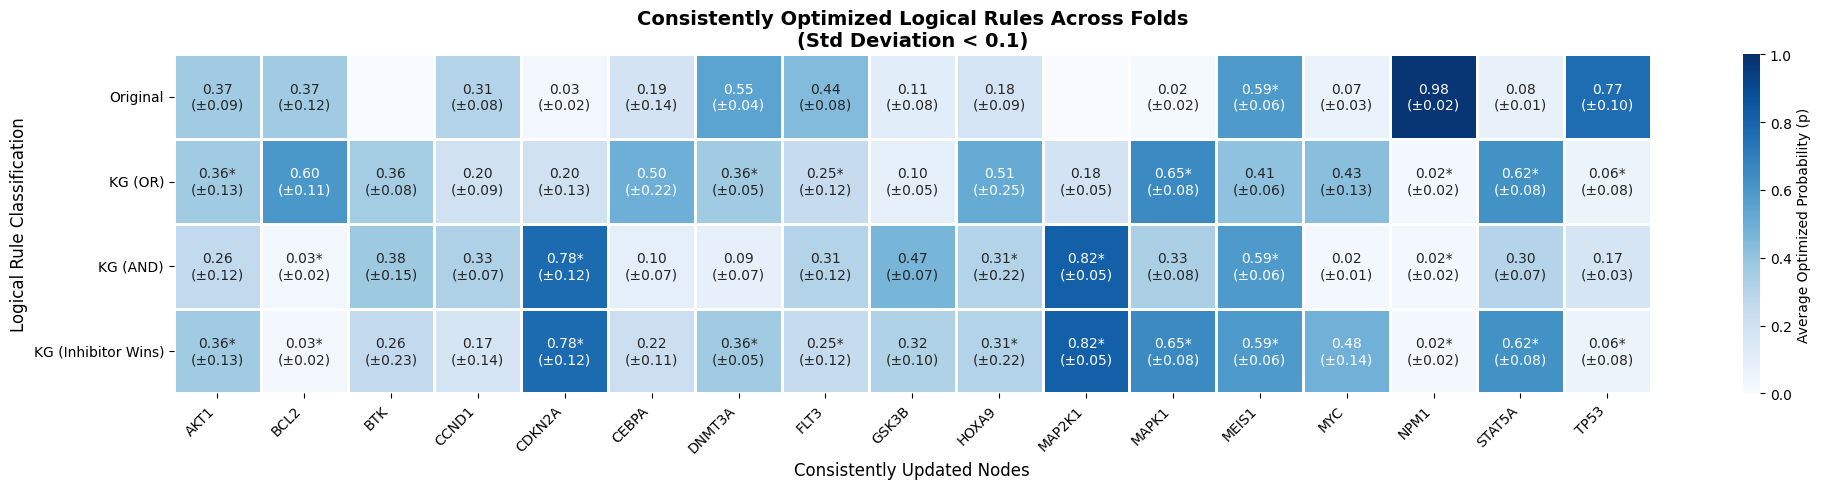

In [ ]:
plot_consistent_probabilities(base_dir='optimization_results/', network_file='inputs/Palma2021.txt', prefix='BeatAML_AUC_5drugs_LOCO',std_threshold=0.1, prob_threshold=0.01, exclude=[7])

In [35]:
pbn = KGBN.load_pbn_from_file('optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/pbn.txt')
formula = KGBN.phenotype_scores(
    genes=pbn.nodeDict.keys(),
    simulation_results=None,
    phenotypes=['APOPTOSIS'],
    reversed=True
)
eval_result = KGBN.evaluate_pbn(pbn, 'inputs/BeatAML_AUC_5drugs_Waves3+4.csv', 
    config=config, 
    Measured_formula=formula['APOPTOSIS'],
    normalize=True,
    output_dir='optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/waves3+4')

No initial state provided, using a random initial state
PBN loaded successfully. There are 24 genes in the network.
Path found for 1 phenotypes: ['APOPTOSIS']
Plot saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/waves3+4/prediction_vs_experimental.png
Residual plot saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/waves3+4/residual_analysis.png
Evaluation report saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/waves3+4/evaluation_report.txt
Results exported to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/waves3+4/detailed_results.csv
PBN saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/waves3+4/pbn.txt


## LODO: leave one drug out

In [ ]:
summary_lodo = generate_cv_summary_table(
    base_dir="optimization_results",
    prefix="BeatAML_AUC_5drugs_LODO",
    meta_csv="inputs/BeatAML_AUC_5drugs.csv",
    mode="LODO",
    save_path="outputs/BeatAML_AUC_5drugs_LODO_summary.csv",
)

summary_lodo

,drug,train_n_exp,train_pearson_r,train_pearson_p,train_mae,train_rmse,test_n_exp,test_pearson_r,test_pearson_p,test_mae,test_rmse,n_patients_mean,n_patients_min,n_patients_max,std_mean,std_min,std_max,n_drugs
4,Venetoclax,32,0.822,8e-09,0.105,0.156,8,0.585,1e-01,0.270,0.304,44.000,5,180,75.989,62.12,91.16,1
2,Midostaurin,32,0.900,2e-12,0.083,0.107,8,0.368,4e-01,0.333,0.421,55.000,8,235,56.176,36.33,69.63,1
1,Ibrutinib,32,0.931,1e-14,0.057,0.089,8,0.169,7e-01,0.372,0.446,51.750,7,220,48.575,38.11,57.04,1
3,Selumetinib,32,0.868,1e-10,0.096,0.120,8,-0.060,9e-01,0.392,0.485,53.125,8,226,71.621,64.12,81.63,1
0,Entospletinib,32,0.878,4e-11,0.092,0.118,8,-0.507,2e-01,0.519,0.588,36.500,5,145,46.215,22.41,61.20,1


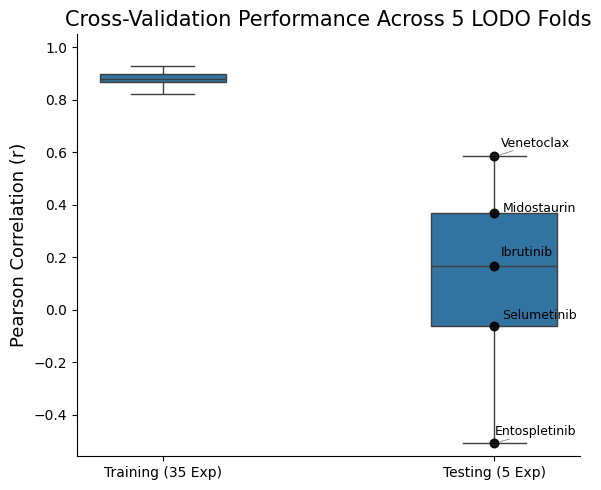

In [37]:
plot_cv_performance(
    base_dir='optimization_results/',
    prefix='BeatAML_AUC_5drugs_LODO',
    mode='LODO')

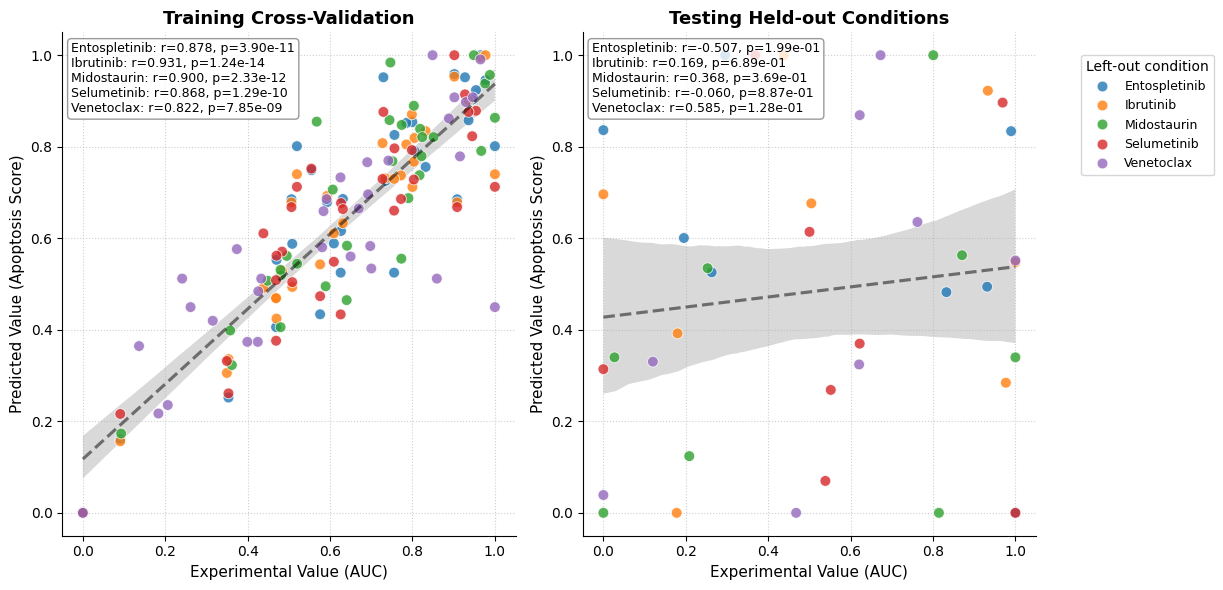

In [38]:
plot_cv_scatter(
    base_dir='optimization_results/',
    prefix='BeatAML_AUC_5drugs_LODO',
    mode='LODO'
)

# Figure 4: Extend to NRAS

No initial state provided, using a random initial state
Network loaded successfully. There are 18 genes in the network.
number of genes found: 25
[2322, 4869, 207, 596, 595, 1029, 1050, 1788, 5594, 2120, 55294, 2932, 3205, 4211, 4609, 6659, 6776, 7157, 596, 6850, 695, 5604, 5605, 4893, 153090]
No initial state provided, using a random initial state
Network loaded successfully. There are 24 genes in the network.
No initial state provided, using a random initial state
PBN loaded successfully. There are 24 genes in the network.
{('AKT1', 'AKT1'): 0.2, ('FLT3', 'AKT1'): 0.431, ('AKT1', 'MAPK1'): 0.532, ('MAPK1', 'MAPK1'): 0.2, ('MAP2K2', 'MAPK1'): 0.745, ('MAP2K1', 'MAPK1'): 0.75, ('AKT1', 'DAB2IP'): 0.497, ('FBXW7', 'DAB2IP'): 0.328, ('AKT1', 'GSK3B'): 0.793, ('MAPK1', 'GSK3B'): 0.384, ('DAB2IP', 'GSK3B'): 0.312, ('GSK3B', 'GSK3B'): 0.2, ('MAP2K1', 'GSK3B'): 0.344, ('MAPK1', 'TP53'): 0.777, ('GSK3B', 'TP53'): 0.727, ('HOXA9', 'MEIS1'): 0.62, ('DNMT3A', 'MEIS1'): 0.328, ('GSK3B', 'CCND1'):

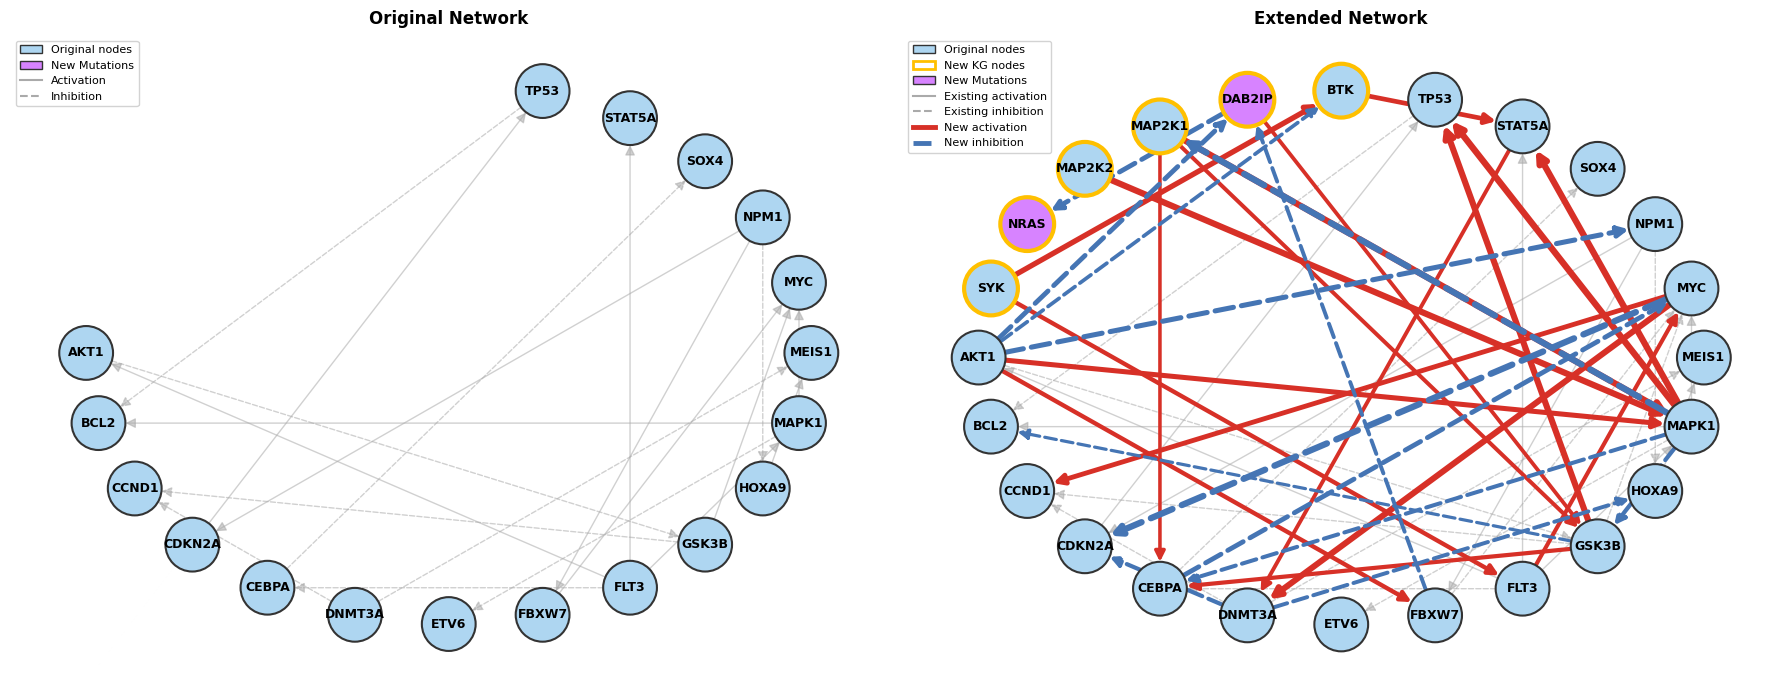

Path found for 1 phenotypes: ['APOPTOSIS']


{'APOPTOSIS': '- AKT1 - BCL2 + CDKN2A + GSK3B - MAPK1 - MEIS1 - NRAS - STAT5A + TP53'}

In [ ]:
# The Palma model
network = KGBN.load_network(network_file)
genes = list(network.nodeDict.keys())

# extended PBN by adding drug targets and NRAS
genes = genes + ['BCL2','SYK', 'BTK','MAP2K1','MAP2K2','NRAS','DAB2IP']

# similarly we created KGs using 3 joiners: AND, OR, Inhibitor Wins
# here only AND model is shown as an example
KG_AND_string, relations = KGBN.load_signor_network(genes, joiner='&', saveto='outputs/KG_evidence.txt')
KG_AND = KGBN.load_network_from_string(KG_AND_string)
pbn_string = KGBN.merge_networks([network, KG_AND], method="PBN", prob=0.6)
pbn = KGBN.load_pbn_from_string(pbn_string)

# Visualize extended PBN
edge_scores_mutations = {(src, tgt): score
               for src, tgt, _, score in relations
               if score is not None}
print(edge_scores_mutations)
KGBN.vis_extension(network, pbn,
                   interactive=False,
                   layout='shell',
                   figsize=(18, 7),
                   color_node='#AED6F1',
                   extension_color_node='#AED6F1',
                   node_groups=
                   {'New Mutations': ({'NRAS', 'DAB2IP'}, '#D783FF')},
                   edge_scores=edge_scores_mutations,
                   )

# get phenotype score formula
formula = KGBN.phenotype_scores(
    genes=pbn.nodeDict.keys(),
    simulation_results=None,
    phenotypes=['APOPTOSIS']
)
formula

In [40]:
# Create dataset with drug response and mutations
sample_mutations = {}
for ptid in mutation_matrix.index:
    mutated_genes = mutation_matrix.loc[ptid][mutation_matrix.loc[ptid] == 1].index.tolist()
    # Filter to only model genes
    # mutated_genes_in_model = [g for g in mutated_genes if g in pbn.nodeDict.keys()]
    mutated_genes_in_model = [g for g in mutated_genes if g in ['FLT3_ITD', 'NPM1', 'DNMT3A', 'NRAS']]
    sample_mutations[ptid] = set(mutated_genes_in_model)

# Create mutation profile mapping
mutation_profiles = []
for _, row in sample_to_ptid.iterrows():
    ptid = row['ptid']
    if ptid in sample_mutations:
        mutation_profiles.append({
            'dbgap_sample_id': row['dbgap_sample_id'],
            'ptid': ptid,
            'mutation_profile': sample_mutations[ptid]
        })

mutation_profile_df = pd.DataFrame(mutation_profiles)

# Merge with drug response data
drug_response_merged = pd.merge(
    mutation_profile_df,
    drug_response,
    left_on='dbgap_sample_id',
    right_on='dbgap_dnaseq_sample',
    how='inner'
)

# Filter for selected drugs of interest
df_nras = drug_response_merged[drug_response_merged['inhibitor'].apply(lambda x: any(drug in x for drug in drugs))].copy()

# Merge cohort information
df_nras = pd.merge(df_nras, sample_to_ptid[['dbgap_sample_id', 'cohort']], on='dbgap_sample_id', how='left')

print(f"dataset: {len(df_nras)} records")
print(f"Drugs: {sorted(df_nras['inhibitor'].unique())}")

dataset: 2383 records
Drugs: ['Entospletinib (GS-9973)', 'Ibrutinib (PCI-32765)', 'Midostaurin', 'Selumetinib (AZD6244)', 'Trametinib (GSK1120212)', 'Venetoclax']


Drug:Entospletinib (GS-9973)


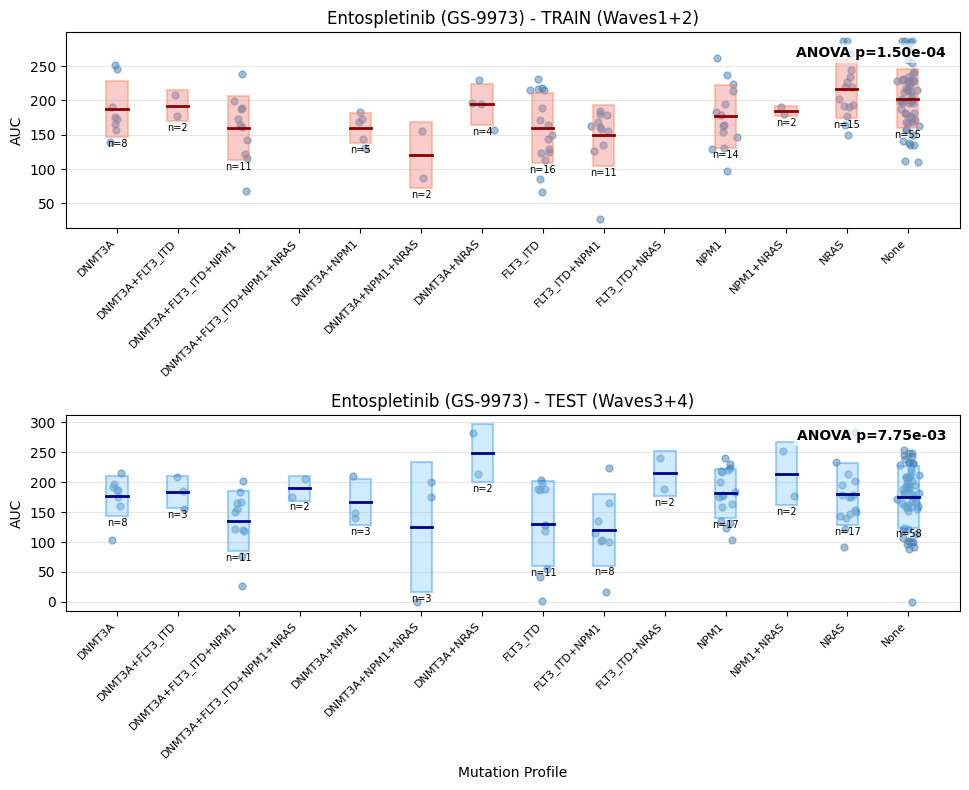

Drug:Ibrutinib (PCI-32765)


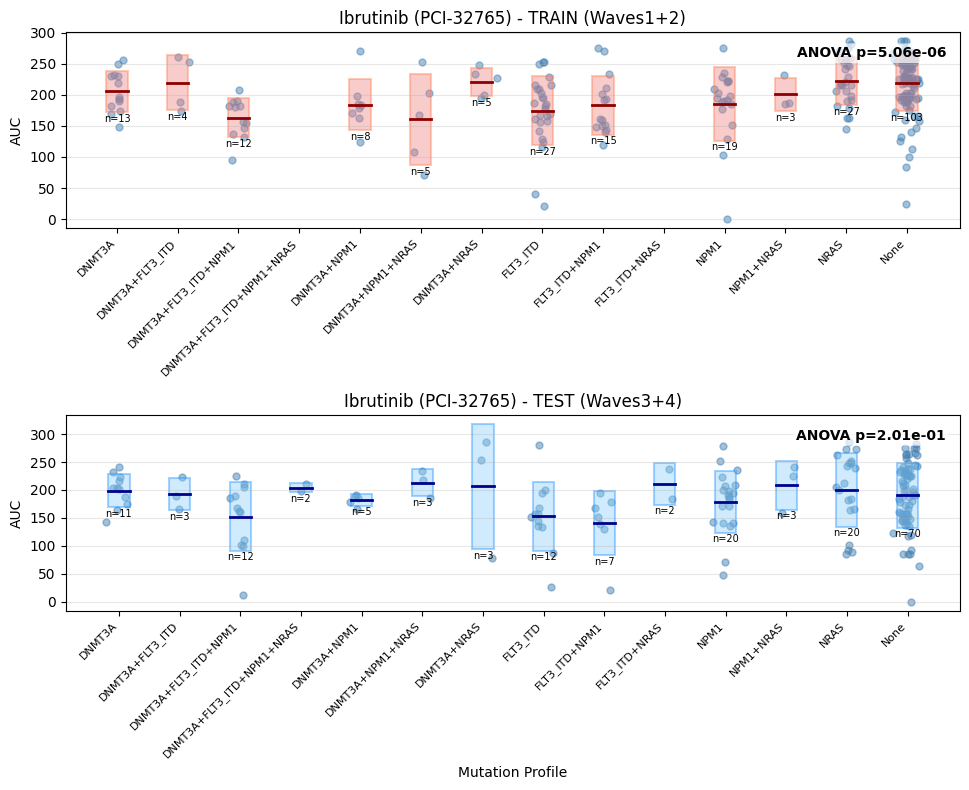

Drug:Midostaurin


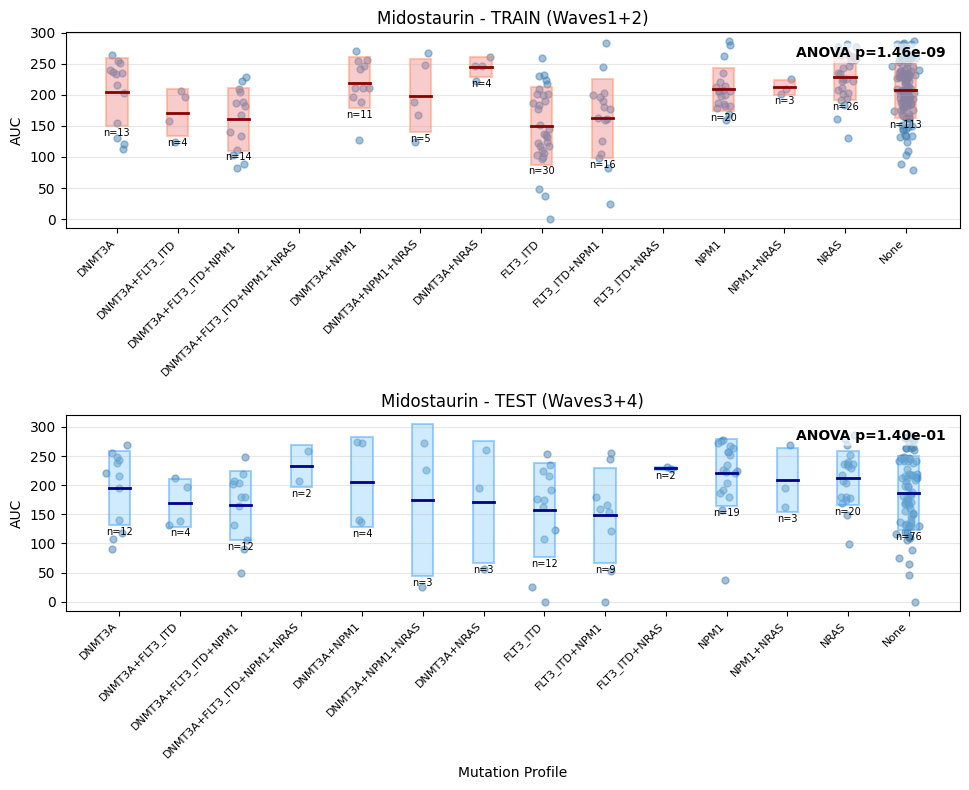

Drug:Selumetinib (AZD6244)


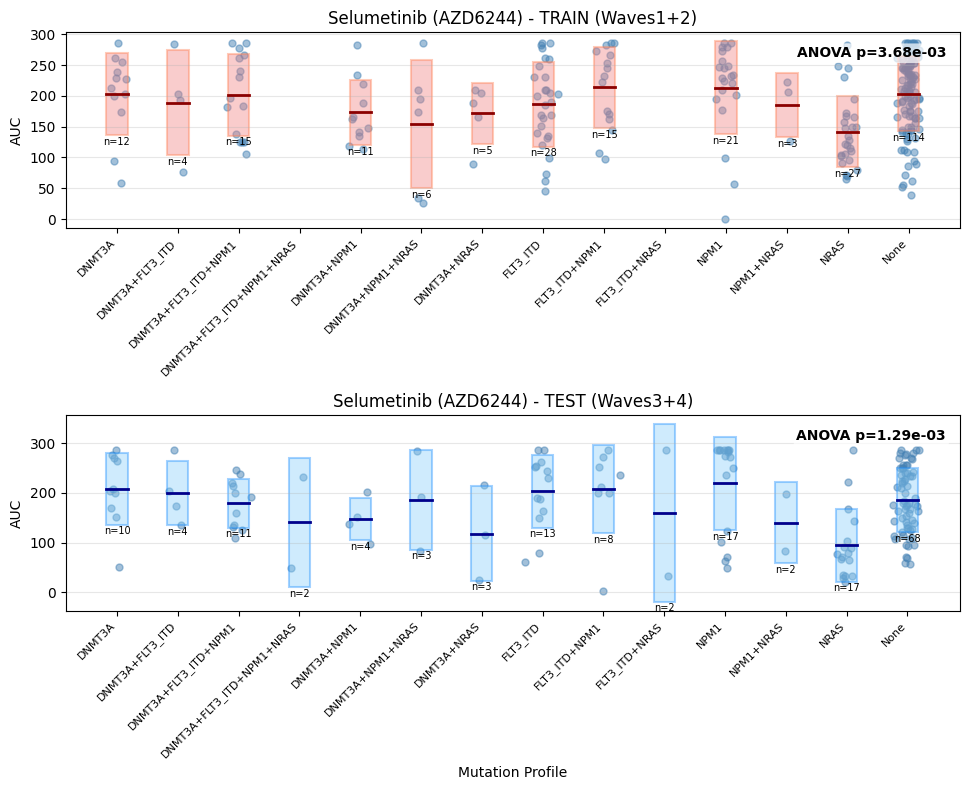

Drug:Trametinib (GSK1120212)


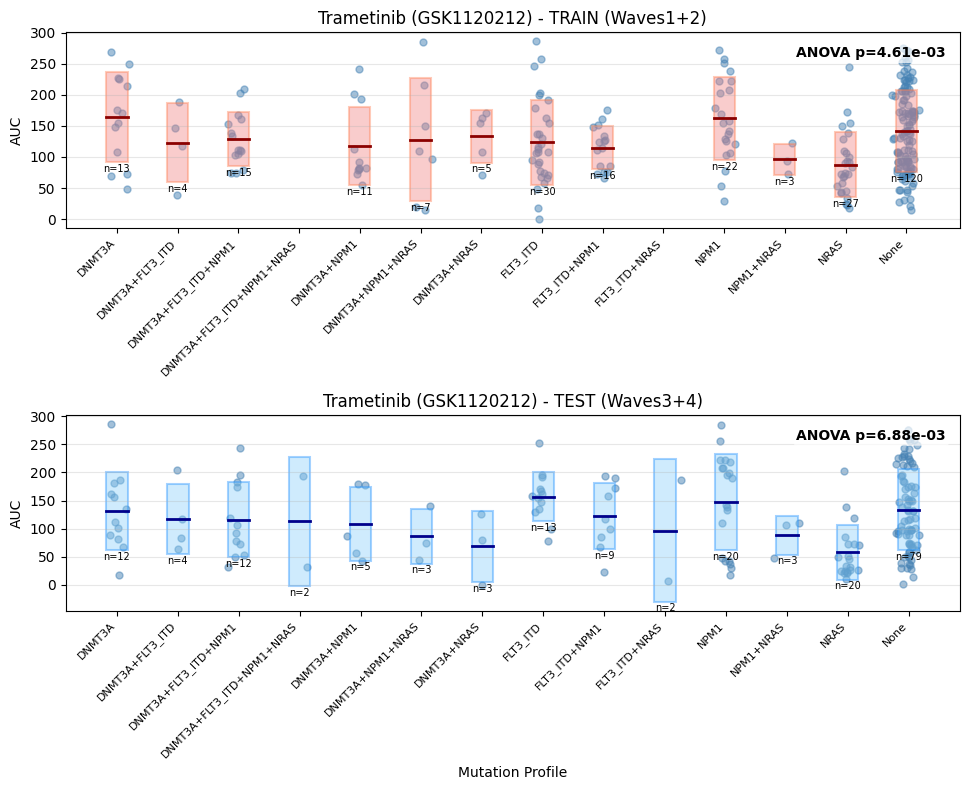

Drug:Venetoclax


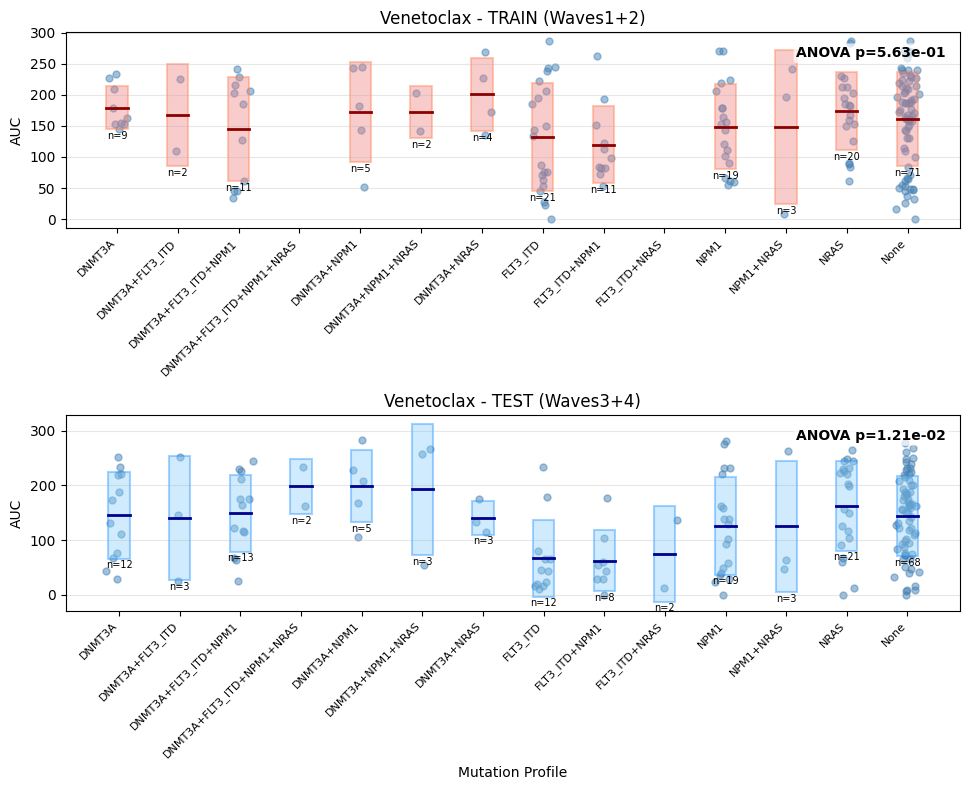

In [41]:
# AUC by mutation profile with mean ± s.d. boxes (Train vs Test)
AUC_by_mutation_profile(df_nras)

In [42]:
exp_data = create_experimental_data(
    df_nras, 
    cohort=None,
    mutation_genes=['FLT3_ITD', 'NPM1', 'DNMT3A', 'NRAS'],
    inhibitors=['Venetoclax', 'Ibrutinib', 'Entospletinib','Selumetinib','Midostaurin'],
    output_file=f'inputs/BeatAML_AUC_5drugs_NRAS_DAB.csv'
)

\nGenerating data for 16 profiles × 5 drugs = 80 experiments
\nSaved 70 experiments to inputs/BeatAML_AUC_5drugs_NRAS_DAB.csv
\nSummary by drug:
               Total patients   Mean AUC±SD
drug                                       
Entospletinib             292  176.51±28.34
Ibrutinib                 414  193.35±19.19
Midostaurin               440  197.71±27.07
Selumetinib               425  177.35±27.93
Venetoclax                352  148.16±35.74


In [44]:
pbn = KGBN.load_pbn_from_file('optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/pbn.txt')
formula = KGBN.phenotype_scores(
    genes=pbn.nodeDict.keys(),
    simulation_results=None,
    phenotypes=['APOPTOSIS'],
    reversed=True
)
eval_result = KGBN.evaluate_pbn(pbn, 'inputs/BeatAML_AUC_5drugs_NRAS_DAB_Waves1+2.csv', 
    config=config, 
    Measured_formula=formula['APOPTOSIS'],
    normalize=True,
    output_dir='optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW')

eval_result = KGBN.evaluate_pbn(pbn, 'inputs/BeatAML_AUC_5drugs_NRAS_DAB_Waves3+4.csv', 
    config=config, 
    Measured_formula=formula['APOPTOSIS'],
    normalize=True,
    output_dir='optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/waves3+4')

No initial state provided, using a random initial state
PBN loaded successfully. There are 25 genes in the network.
Path found for 1 phenotypes: ['APOPTOSIS']
Plot saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/prediction_vs_experimental.png
Residual plot saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/residual_analysis.png
Evaluation report saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/evaluation_report.txt
Results exported to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/detailed_results.csv
PBN saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/pbn.txt
Plot saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5

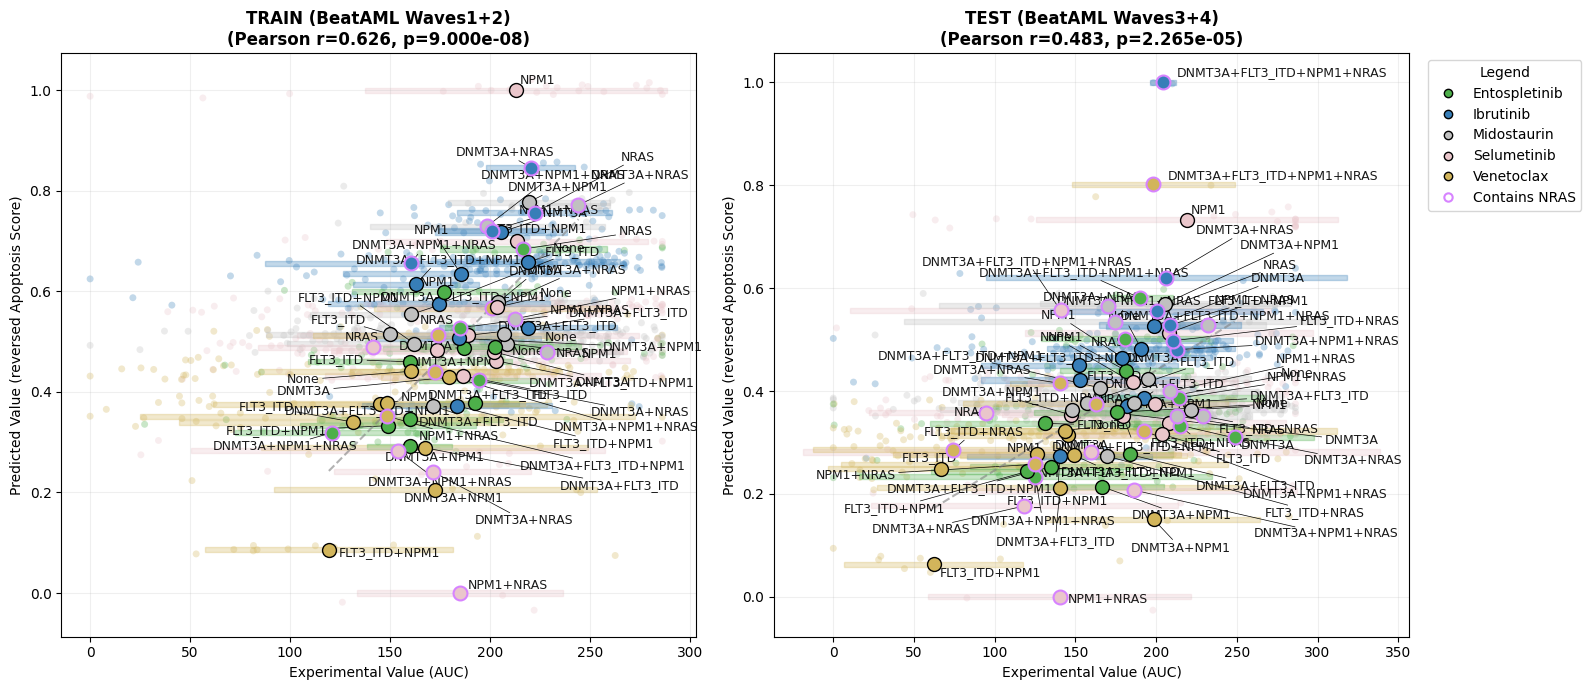

In [46]:
extended_gene = 'NRAS'
expanded_plot_beataml(
    drug='5drugs', 
    df=df_nras, 
    drug2target=drug2target, 
    text_size=9,
    extended_gene=extended_gene,
    use_spearman=False,
    save_path=f'optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/prediction_vs_experimental_individual.png'
)

In [48]:
# Compare the NRAS PBN with the previous PBN
prev_pbn = KGBN.load_pbn_from_file('optimization_results/BeatAML_-AUC_5drugs_Waves1+2_AND+OR+IW/pbn.txt')
nras_pbn = KGBN.load_pbn_from_file('optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/pbn.txt')
prev_cij=prev_pbn.cij
nras_cij=nras_pbn.cij
nodes = prev_pbn.nodeDict.keys() & nras_pbn.nodeDict.keys()
# Compute the absolute difference for each node
diff_dict = {}
for node in nodes:
    prev_vals = prev_cij[prev_pbn.nodeDict[node]]
    nras_vals = nras_cij[nras_pbn.nodeDict[node]]
    diff = np.abs(prev_vals - nras_vals)
    diff_sum = np.sum(diff)
    diff_dict[node] = {
        'prev_cij': prev_vals,
        'nras_cij': nras_vals,
        'diff_sum': diff_sum
    }

# Rank nodes from largest to smallest difference
ranked = sorted(diff_dict.items(), key=lambda x: x[1]['diff_sum'], reverse=True)
output_dict = {node: { 'prev': vals['prev_cij'], 'nras': vals['nras_cij']} for node, vals in ranked}

cols = ['prev', 'nras']
rows = []
for gene, gene_dict in output_dict.items():
    max_len = max(len(v) for v in gene_dict.values())
    for i in range(max_len):
        row = {'gene': gene, 'row': i}
        for c in cols:
            arr = gene_dict.get(c, [])
            row[c] = round(arr[i], 3) if arr[i]>0 else '-'
        rows.append(row)
df_diff = pd.DataFrame(rows).set_index(['gene', 'row'])

def build_rhs_map(eqs):
    """Return dict: gene -> [rhs0, rhs1, ...] in the order they appear."""
    rhs_map = {}
    for s in eqs:
        m = re.match(r'^\s*([^=]+?)\s*=\s*(.+?)\s*$', s)
        if not m:
            continue
        lhs = m.group(1).strip()
        rhs = m.group(2).strip()
        rhs_map.setdefault(lhs, []).append(rhs)
    return rhs_map

def rhs_at(rhs_map, gene, row):
    lst = rhs_map.get(gene, [])
    return lst[row] if row < len(lst) else None

rhs_base_map = build_rhs_map(prev_pbn.equations)
rhs_nras_map = build_rhs_map(nras_pbn.equations)

df_out = df_diff.copy()

# add equation columns (RHS only)
base_rhs = [rhs_at(rhs_base_map, g, r) for g, r in df_out.index]
nras_rhs = [rhs_at(rhs_nras_map, g, r) for g, r in df_out.index]

df_out["equation"] = [x if x is not None else "-" for x in base_rhs]
df_out["equation_nras"] = [x if x is not None else "-" for x in nras_rhs]

# combine if identical and not empty
same = (df_out["equation"] == df_out["equation_nras"]) & (df_out["equation"] != "-")
df_out.loc[same, "equation_nras"] = "-"

# (optional) put them as the first two columns
front = ["equation", "equation_nras"]
df_out = df_out[front + [c for c in df_out.columns if c not in front]]
# remove rows where both equation and equation_nras are '-'
df_out = df_out[~((df_out["equation"] == "-") & (df_out["equation_nras"] == "-"))]

df_out.to_csv('outputs/nras_diff.csv')

No initial state provided, using a random initial state
PBN loaded successfully. There are 24 genes in the network.
No initial state provided, using a random initial state
PBN loaded successfully. There are 25 genes in the network.


## LOCO

In [50]:
summary_nras_loco = generate_cv_summary_table(
    base_dir="optimization_results",
    prefix="BeatAML_AUC_5drugs_NRAS_DAB_LOCO",
    meta_csv="inputs/BeatAML_AUC_5drugs_NRAS_DAB.csv",
    mode="LOCO",
    save_path="outputs/BeatAML_AUC_5drugs_NRAS_DAB_LOCO_summary.csv",
)

summary_nras_loco

,mutation_profile,train_n_exp,train_pearson_r,train_pearson_p,train_mae,train_rmse,test_n_exp,test_pearson_r,test_pearson_p,test_mae,test_rmse,n_patients_mean,n_patients_min,n_patients_max,std_mean,std_min,std_max,n_drugs,drug_level_detail
0,NRAS,65,0.509,1e-05,0.140,0.183,5,0.923,3e-02,0.119,0.156,42.0,32,47,56.940,42.10,72.48,5,"Venetoclax (n=41, sd=72.48); Ibrutinib (n=47, ..."
13,"FLT3_ITD,NRAS",65,0.508,2e-05,0.152,0.194,5,0.911,3e-02,0.113,0.162,2.0,2,2,68.516,2.35,178.70,5,"Venetoclax (n=2, sd=87.19); Ibrutinib (n=2, sd..."
3,NPM1,65,0.529,6e-06,0.142,0.184,5,0.806,1e-01,0.262,0.347,37.0,31,39,61.706,42.83,83.03,5,"Venetoclax (n=38, sd=79.42); Ibrutinib (n=39, ..."
12,FLT3_ITD,65,0.522,8e-06,0.138,0.182,5,0.655,2e-01,0.252,0.306,36.4,27,42,68.210,57.42,86.20,5,"Venetoclax (n=33, sd=86.2); Ibrutinib (n=39, s..."
1,DNMT3A,65,0.523,8e-06,0.141,0.187,5,0.526,4e-01,0.271,0.414,21.6,16,25,51.750,31.22,67.78,5,"Venetoclax (n=21, sd=64.97); Ibrutinib (n=24, ..."
2,"FLT3_ITD,NPM1",65,0.528,6e-06,0.131,0.177,5,0.488,4e-01,0.265,0.343,21.6,19,25,62.398,51.73,72.49,5,"Venetoclax (n=19, sd=64.62); Ibrutinib (n=22, ..."
10,"DNMT3A,NPM1",65,0.561,1e-06,0.135,0.179,5,0.453,4e-01,0.284,0.402,12.2,8,15,45.950,26.24,70.93,5,"Venetoclax (n=10, sd=70.93); Ibrutinib (n=13, ..."
7,"DNMT3A,FLT3_ITD",65,0.519,1e-05,0.144,0.187,5,0.425,5e-01,0.326,0.387,6.6,5,8,51.644,22.41,91.16,5,"Venetoclax (n=5, sd=91.16); Ibrutinib (n=7, sd..."
5,No mutation,65,0.636,1e-08,0.134,0.166,5,0.351,6e-01,0.364,0.422,159.2,113,189,58.684,49.46,74.76,5,"Venetoclax (n=139, sd=74.76); Ibrutinib (n=173..."
8,"DNMT3A,FLT3_ITD,NPM1",65,0.553,2e-06,0.138,0.182,5,0.286,6e-01,0.408,0.493,24.4,22,26,56.976,47.83,74.95,5,"Venetoclax (n=24, sd=74.95); Ibrutinib (n=24, ..."


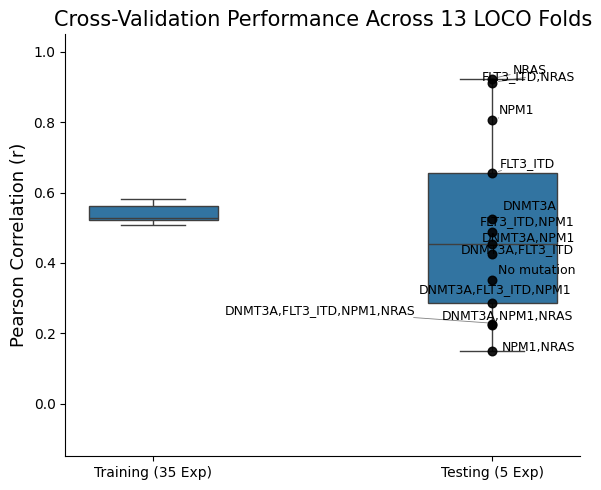

In [51]:
plot_cv_performance(
    base_dir='optimization_results/',
    prefix='BeatAML_AUC_5drugs_NRAS_DAB_LOCO',
    mode='LOCO'
)

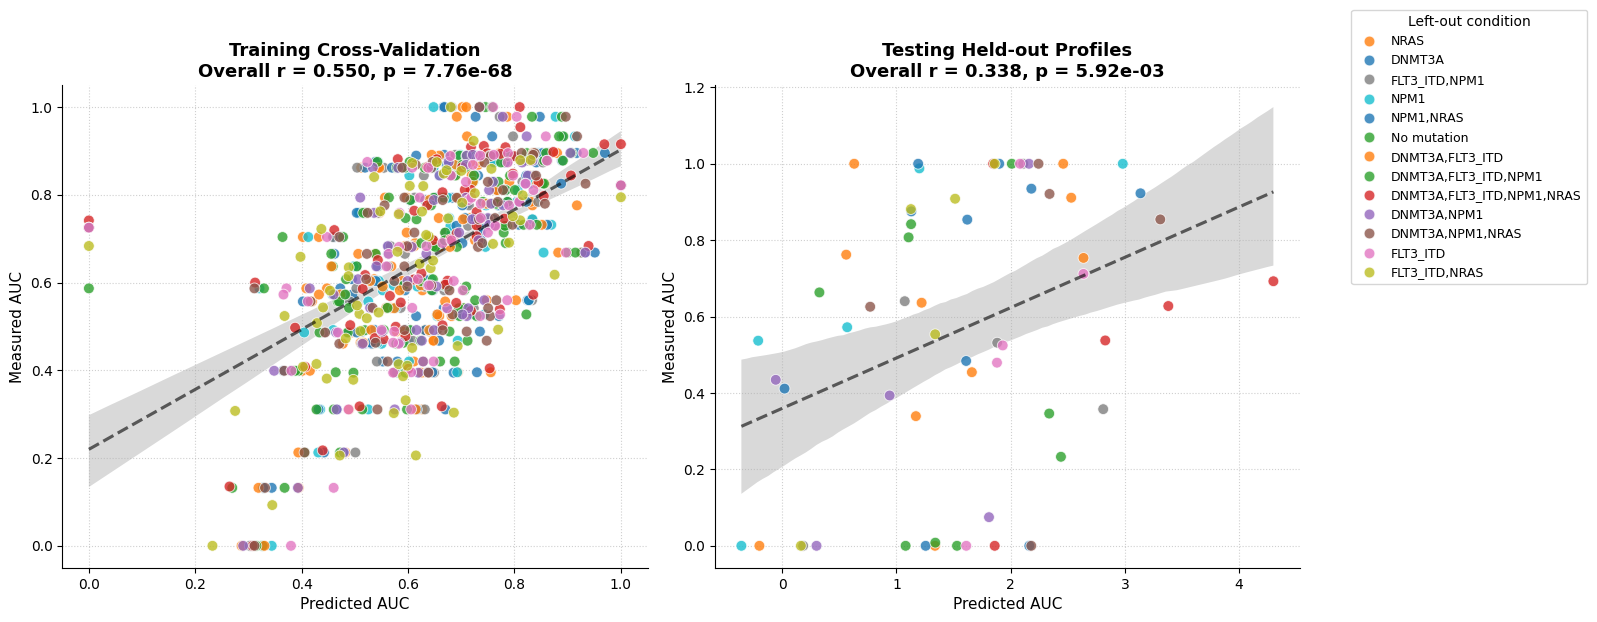

In [52]:
plot_cv_scatter(base_dir='optimization_results/', prefix='BeatAML_AUC_5drugs_NRAS_DAB_LOCO',combined=True)

Rebuilding baseline knowledge graphs to categorize rules...
No initial state provided, using a random initial state
Network loaded successfully. There are 18 genes in the network.
number of genes found: 26
[2322, 4869, 207, 596, 595, 1029, 1050, 1788, 5594, 2120, 55294, 2932, 3205, 4211, 4609, 6659, 6776, 7157, 596, 6850, 695, 5604, 5605, 3815, 4893, 153090]
number of genes found: 26
[2322, 4869, 207, 596, 595, 1029, 1050, 1788, 5594, 2120, 55294, 2932, 3205, 4211, 4609, 6659, 6776, 7157, 596, 6850, 695, 5604, 5605, 3815, 4893, 153090]
number of genes found: 26
[2322, 4869, 207, 596, 595, 1029, 1050, 1788, 5594, 2120, 55294, 2932, 3205, 4211, 4609, 6659, 6776, 7157, 596, 6850, 695, 5604, 5605, 3815, 4893, 153090]
No initial state provided, using a random initial state
Network loaded successfully. There are 25 genes in the network.
No initial state provided, using a random initial state
Network loaded successfully. There are 25 genes in the network.
No initial state provided, using a ra

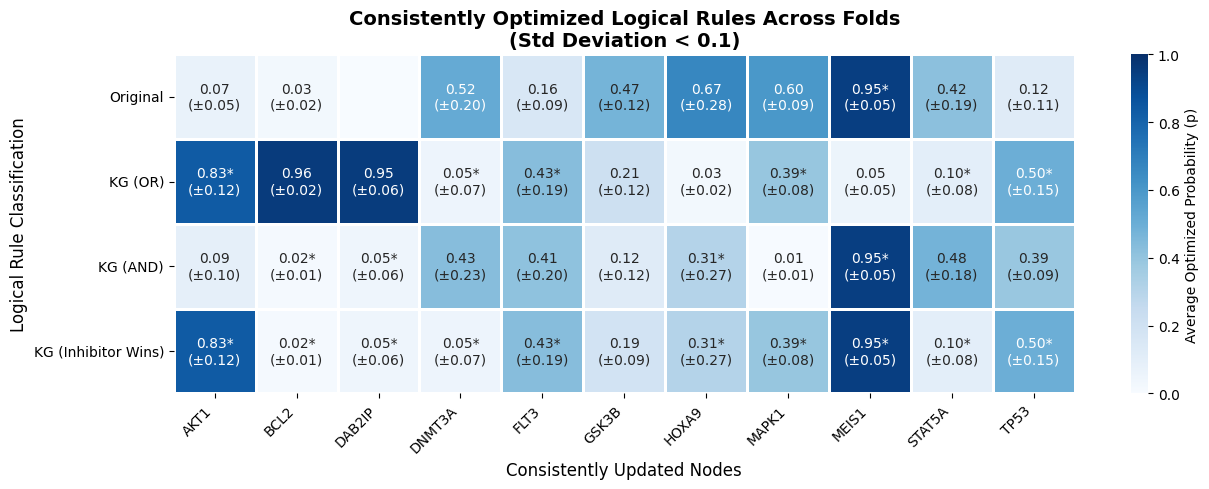

In [53]:
base_dir='optimization_results/'
plot_consistent_probabilities(base_dir, network_file, extended_genes = ['NRAS','DAB2IP'], prefix='BeatAML_AUC_5drugs_NRAS_DAB_LOCO',std_threshold=0.1, prob_threshold=0.01)

# External validation: FPMTB data
https://zenodo.org/records/7370747

In [54]:
df_mutation = pd.read_excel('inputs/Functional_Precision_Medicine_Tumor_Board_AML/File_6_Binary_mutation_225S_57G.xlsx',index_col=0)
df_dss = pd.read_excel('inputs/Functional_Precision_Medicine_Tumor_Board_AML/File_3.1_Drug_response_sDSS_164S_17Healthy.xlsx',index_col=0)
df_dss.set_index('Drug_name',inplace=True)

In [55]:
gene_of_interest = ['FLT3','NPM1','DNMT3A']

# Filter mutations to genes of interest
genes_to_use = df_mutation.index.intersection(gene_of_interest)
df_mut_filt = df_mutation.loc[genes_to_use]

# Build mutation_profile per sample (set of mutated genes)
mutation_profile = df_mut_filt.apply(
    lambda col: {gene for gene, val in col.items() if val == 1},
    axis=0
)

# Filter DSS to selected drugs
drugs_to_use = df_dss.index.intersection(drugs)
df_dss_filt = df_dss.loc[drugs_to_use]

# Long-format DSS: one row per (sample, drug)
df_long = (
    df_dss_filt
    .reset_index()    
    .rename(columns={'index': 'drug'})
    .melt(id_vars='Drug_name',
          var_name='sample_id',
          value_name='DSS')
)

# drop missing DSS values
df_long = df_long.dropna(subset=['DSS'])

# Add mutation_profile column
df_long['mutation_profile'] = df_long['sample_id'].map(mutation_profile)
df_long = df_long.dropna(subset=['mutation_profile'])
df_long.to_csv('inputs/FPMTB_sDSS_5drugs_min5_df.csv',index=False)
df_long['mutation_profile'].value_counts()

mutation_profile
{}                      513
{DNMT3A}                 64
{NPM1}                   49
{DNMT3A, NPM1}           33
{FLT3}                   30
{DNMT3A, FLT3}           21
{NPM1, FLT3}             18
{DNMT3A, NPM1, FLT3}     15
Name: count, dtype: int64

In [56]:
def create_FPMTB(df, gene_of_interest,
                    inhibitors=['Venetoclax'],
                    drug2target=None,
                    min_patients=3,
                    output_file='beataml_experiments.csv'):
    """
    Create experimental data CSV from FPMTB drug response data.
    
    Parameters:
    - df: DataFrame with mutation_profile, Drug_name, and DSS columns
    - gene_of_interest: List of genes
    - inhibitors: List of drug names
    - min_patients: Minimum number of patients per profile
    - output_file: Output CSV filename
    
    Note: Oncogenes become Stimuli, TSGs become Inhibitors based on gene_to_class
    """
    
    # Drug to target mapping
    if drug2target is None:
        drug2target = {
            'Venetoclax': ['BCL2'],
            'Ibrutinib': ['BTK'], 
            'Entospletinib': ['SYK'],
            }

    # mutation class
    classification = pd.read_csv("inputs/Palma_class_extended.csv")
    gene_to_class = dict(zip(classification['symbol'], classification['class']))
        
    # Normalize profile text for comparison
    def normalize_profile_text(p):
        if isinstance(p, (set, frozenset, list, tuple)):
            genes = sorted(map(str, p))
        else: 
            s = re.sub(r'[\\{\\}]', '', str(p))
            genes = sorted([g.strip() for g in s.split(',') if g.strip()])
        return set(genes) if genes else set()
    
    df_work = df.copy()
    df_work['profile_set'] = df_work['mutation_profile'].apply(normalize_profile_text)
   
    # Generate all mutation profile combinations
    from itertools import combinations
    all_profiles = []
    for r in range(len(gene_of_interest) + 1):
        for combo in combinations(gene_of_interest, r):
            all_profiles.append(set(combo))
    
    print(f"\nGenerating data for {len(all_profiles)} profiles × {len(inhibitors)} drugs = {len(all_profiles) * len(inhibitors)} experiments")
    
    # Create experiment rows
    experiments = []
    exp_id = 1
    
    for profile in all_profiles:
        for drug in inhibitors:
            # Filter data for this profile and drug
            matching_data = df_work[
                (df_work['profile_set'] == profile) & 
                (df_work['Drug_name'] == drug)
            ]
            
            if len(matching_data) == 0:
                continue
            
            # Calculate average AUC
            avg_dss = matching_data['DSS'].mean()
            std_dss = matching_data['DSS'].std()
            n_patients = len(matching_data)            
            if min_patients is not None and n_patients < min_patients:
                print(f"Not enough patients for {drug} {profile}, skipping...")
                continue
            
            # Classify genes as oncogenes or TSGs
            oncogenes = []
            tsgs = []
            
            for gene in profile:
                gene_class = gene_to_class.get(gene, 'unknown')
                if gene_class == 'oncogene':
                    oncogenes.append(gene)
                elif gene_class == 'TSG':
                    tsgs.append(gene)
                else:
                    print(f"Warning: Unknown classification for {gene}, treating as oncogene")
                    oncogenes.append(gene)
            
            # Oncogenes → Stimuli (activate)
            stimuli = ','.join(sorted(oncogenes)) if oncogenes else ''
            stimuli_efficacy = ','.join(['1'] * len(oncogenes)) if oncogenes else ''
            
            # TSGs + Drug target → Inhibitors (knockdown)
            target = drug2target.get(drug, '')
            if not target:
                print(f"Warning: No target mapping for {drug}, skipping...")
                continue
            
            all_inhibitors = sorted(tsgs + target)
            inhibitors_str = ','.join(all_inhibitors)
            inhibitors_efficacy = ','.join(['1'] * len(all_inhibitors))
            
            measured_nodes = 'DSS'
            measured_values = f'{avg_dss:.2f}'
            
            experiments.append({
                'Experiments': exp_id,
                'Stimuli': stimuli,
                'Stimuli_efficacy': stimuli_efficacy,
                'Inhibitors': inhibitors_str,
                'Inhibitors_efficacy': inhibitors_efficacy,
                'Measured_nodes': measured_nodes,
                'Measured_values': measured_values,
                'n_patients': n_patients,
                'std': f'{std_dss:.2f}',
                'drug': drug
            })
            
            exp_id += 1
    
    # Create DataFrame
    exp_df = pd.DataFrame(experiments)
    
    # Save to CSV
    exp_df.to_csv(output_file, index=False)
    
    print(f"\nSaved {len(exp_df)} experiments to {output_file}")
    print(f"\nSummary by drug:")
    print(exp_df.groupby('drug').agg({
        'n_patients': 'sum',
        'Measured_values': lambda x: f"{pd.to_numeric(x).mean():.2f}±{pd.to_numeric(x).std():.2f}"
    }).rename(columns={'Measured_values': 'Mean DSS±SD', 'n_patients': 'Total patients'}))
    
    return exp_df 

def expanded_plot(data_df, df_long, eval_result, drug2target, extended_gene=None, use_spearman=False, save_path=None):
    # Expanded plot: show individual samples instead of aggregated experiments
    import numpy as np
    from scipy import stats
    from scipy.stats import spearmanr
    from adjustText import adjust_text
    
    # Color for highlighting points containing extended_gene in their label
    highlight_color = '#D783FF'

    def normalize_profile_text(p):
        """Normalize mutation profile to consistent text format"""
        if isinstance(p, (set, frozenset, list, tuple)):
            genes = sorted(map(str, p))
        else:
            s = re.sub(r'[\{\}]', '', str(p))
            genes = sorted([g.strip() for g in s.split(',') if g.strip()])
        return "+".join(genes) if genes else "None"

    # Get predicted values from eval_result
    sim_results = eval_result['simulation_results']
    exp_ids = sim_results['experiment_ids']

    # Min-max normalize predicted values to 0-1
    def minmax_normalize(values):
        arr = np.array(values)
        min_val = np.min(arr)
        max_val = np.max(arr)
        if max_val - min_val == 0:
            return np.zeros_like(arr, dtype=float)
        return (arr - min_val) / (max_val - min_val)
    predicted_values = minmax_normalize(sim_results['predicted_values'])

    # Create mapping: experiment_id -> predicted_value
    exp_to_pred = dict(zip(exp_ids, predicted_values))

    # Also get the profile_label and drug for each experiment from data_df
    all_drug_targets = set()
    for targets in drug2target.values():
        all_drug_targets.update(targets)

    def get_profile_label_from_row(row):
        """Extract mutation profile from Stimuli and Inhibitors columns"""
        mutated_genes = set()
        stimuli = str(row.get('Stimuli', ''))
        if stimuli and stimuli != 'nan':
            for gene in stimuli.split(','):
                gene = gene.strip()
                if gene:
                    mutated_genes.add(gene)
        inhibitors = str(row.get('Inhibitors', ''))
        if inhibitors and inhibitors != 'nan':
            for gene in inhibitors.split(','):
                gene = gene.strip()
                if gene and gene not in all_drug_targets:
                    mutated_genes.add(gene)
        if mutated_genes:
            return '+'.join(sorted(mutated_genes))
        return 'None'

    data_df['profile_label'] = data_df.apply(get_profile_label_from_row, axis=1)
    data_df['predicted'] = data_df['Experiments'].map(exp_to_pred)

    # Create mapping: (profile_label, drug) -> predicted_value
    profile_drug_to_pred = {}
    for _, row in data_df.iterrows():
        key = (row['profile_label'], row['drug'])
        profile_drug_to_pred[key] = row['predicted']

    # Map individual samples in df_long to predicted values
    df_samples = df_long.copy()
    df_samples['profile_label'] = df_samples['mutation_profile'].apply(normalize_profile_text)
    print(df_samples['profile_label'].unique())
    df_samples['profile_drug'] = list(zip(df_samples['profile_label'], df_samples['Drug_name']))
    df_samples['predicted'] = df_samples['profile_drug'].map(profile_drug_to_pred)
    df_samples = df_samples.dropna(subset=['predicted', 'DSS'])

    print(f"Matched {len(df_samples)} individual samples to predictions")

    # Create the expanded plot
    fig, ax = plt.subplots(figsize=(7, 7))

    # Define colors for each drug
    drug_colors = {
        'Venetoclax': '#D2B55B',   # Yellow
        'Ibrutinib': '#377EB8',    # Blue
        'Entospletinib': '#4DAF4A', # Green
        'Selumetinib': '#EAC6CB',  # Purple
        'Midostaurin': '#C0C0C0',  # Gray
        # 'Trametinib': '#E3AFC2',   # Pink
    }

    # Plot individual samples with jitter on y-axis
    np.random.seed(42) 
    for _, row in df_samples.iterrows():
        y_jitter = row['predicted'] + np.random.normal(0, 0.015)
        if extended_gene is not None and extended_gene in row['profile_label'].split('+'):
            color = highlight_color
        else:
            color = drug_colors.get(row['Drug_name'], 'gray')
        ax.scatter(row['DSS'], y_jitter, alpha=0.4, s=30, color=color)

    # Calculate and plot mean ± s.d. for each profile-drug combination
    profile_drug_means = df_samples.groupby(['profile_label', 'Drug_name']).agg({
        'DSS': ['mean', 'std', 'count'],
        'predicted': 'first'
    }).reset_index()
    profile_drug_means.columns = ['profile_label', 'Drug_name', 'DSS_mean', 'DSS_std', 'count', 'predicted']

    # Correlation on means (Spearman or Pearson based on option)
    if use_spearman:
        r, p_value = spearmanr(profile_drug_means['DSS_mean'], profile_drug_means['predicted'])
        corr_label = 'Spearman'
    else:
        r, p_value = stats.pearsonr(profile_drug_means['DSS_mean'], profile_drug_means['predicted'])
        corr_label = 'Pearson'

    box_height = 0.01
    texts = []
    for _, row in profile_drug_means.iterrows():
        # print(f"drug: {row['Drug_name']}, profile: {row['profile_label']}, n: {row['count']}")
        mean_val = row['DSS_mean']
        std_val = row['DSS_std'] if pd.notna(row['DSS_std']) else 0
        pred = row['predicted']
        base_color = drug_colors.get(row['Drug_name'], 'gray')
        if extended_gene is not None and extended_gene in row['profile_label'].split('+'):
            marker_facecolor = highlight_color
            edgecolor = highlight_color
        else:
            marker_facecolor = base_color
            edgecolor = 'black'        
        
        # Horizontal patch for mean ± s.d. in DSS (like in pred_vs_exp)
        ax.add_patch(plt.Rectangle((mean_val - std_val, pred - box_height/2), 
                                    2*std_val, box_height, 
                                    facecolor=color, alpha=0.3, 
                                    linewidth=1.5, edgecolor=color))
        # Vertical line at mean
        ax.plot([mean_val, mean_val], [pred - box_height/2, pred + box_height/2], 
                color='darkred', linewidth=2, zorder=10)
        
        # Mean marker
        ax.scatter(mean_val, pred, s=100, color=marker_facecolor, edgecolor=edgecolor, linewidth=1.5, zorder=15)
        
        # Collect text annotations for adjustText
        txt = ax.text(mean_val, pred, f'{row["profile_label"]} (n={int(row["count"])})      ', 
                     fontsize=7, alpha=0.8, ha='right', va='top')
        texts.append(txt)
    
    # Adjust text positions to avoid overlap
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    # Regression line
    slope, intercept, _, _, _ = stats.linregress(df_samples['DSS'], df_samples['predicted'])
    x_reg = np.linspace(df_samples['DSS'].min(), df_samples['DSS'].max(), 100)
    y_reg = slope * x_reg + intercept
    ax.plot(x_reg, y_reg, 'k--', linewidth=1.5, alpha=0.6, label='Regression line')

    # Legend for drugs
    legend_handles = [plt.scatter([], [], c=color, s=60, label=drug) 
                    for drug, color in drug_colors.items()]
    ax.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.98, 1), fontsize=9)

    ax.set_xlabel('Experimental Value (DSS)', fontsize=11)
    ax.set_ylabel('Predicted Value (reversed Apoptosis Score)', fontsize=11)
    ax.set_title(f'TEST (FPMTB)\n({corr_label} r={r:.3f}, p={p_value:.3e})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

In [57]:
create_FPMTB(df_long, gene_of_interest = gene_of_interest,
                            inhibitors=['Ibrutinib','Entospletinib','Venetoclax','Selumetinib','Midostaurin'],
                            drug2target=drug2target,
                            min_patients=5,
                            output_file='inputs/FPMTB_sDSS_5drugs_min5.csv')


Generating data for 8 profiles × 5 drugs = 40 experiments
Not enough patients for Entospletinib {'FLT3'}, skipping...
Not enough patients for Venetoclax {'FLT3'}, skipping...
Not enough patients for Ibrutinib {'NPM1', 'FLT3'}, skipping...
Not enough patients for Entospletinib {'NPM1', 'FLT3'}, skipping...
Not enough patients for Venetoclax {'NPM1', 'FLT3'}, skipping...
Not enough patients for Selumetinib {'NPM1', 'FLT3'}, skipping...
Not enough patients for Midostaurin {'NPM1', 'FLT3'}, skipping...
Not enough patients for Ibrutinib {'DNMT3A', 'FLT3'}, skipping...
Not enough patients for Entospletinib {'DNMT3A', 'FLT3'}, skipping...
Not enough patients for Venetoclax {'DNMT3A', 'FLT3'}, skipping...
Not enough patients for Selumetinib {'DNMT3A', 'FLT3'}, skipping...
Not enough patients for Midostaurin {'DNMT3A', 'FLT3'}, skipping...
Not enough patients for Entospletinib {'DNMT3A', 'NPM1'}, skipping...
Not enough patients for Ibrutinib {'DNMT3A', 'NPM1', 'FLT3'}, skipping...
Not enough p

,Experiments,Stimuli,Stimuli_efficacy,Inhibitors,Inhibitors_efficacy,Measured_nodes,Measured_values,n_patients,std,drug
0,1,,,BTK,1,DSS,0.71,90,1.61,Ibrutinib
1,2,,,SYK,1,DSS,0.43,52,1.19,Entospletinib
2,3,,,BCL2,1,DSS,8.04,78,9.61,Venetoclax
3,4,,,"MAP2K1,MAP2K2","1,1",DSS,5.50,99,6.41,Selumetinib
4,5,,,"FLT3,KIT","1,1",DSS,5.55,95,6.04,Midostaurin
5,6,FLT3,1,BTK,1,DSS,0.72,5,1.61,Ibrutinib
6,7,FLT3,1,"MAP2K1,MAP2K2","1,1",DSS,2.02,7,1.81,Selumetinib
7,8,FLT3,1,"FLT3,KIT","1,1",DSS,5.27,6,2.54,Midostaurin
8,9,,,"BTK,NPM1","1,1",DSS,0.43,9,0.72,Ibrutinib
9,10,,,"NPM1,SYK","1,1",DSS,1.07,6,2.24,Entospletinib


## Extend to drug targets

No initial state provided, using a random initial state
PBN loaded successfully. There are 24 genes in the network.
Path found for 1 phenotypes: ['APOPTOSIS']
Plot saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_min5/prediction_vs_experimental.png
Residual plot saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_min5/residual_analysis.png
Evaluation report saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_min5/evaluation_report.txt
Results exported to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_min5/detailed_results.csv
PBN saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_min5/pbn.txt
['None' 'FLT3' 'DNMT

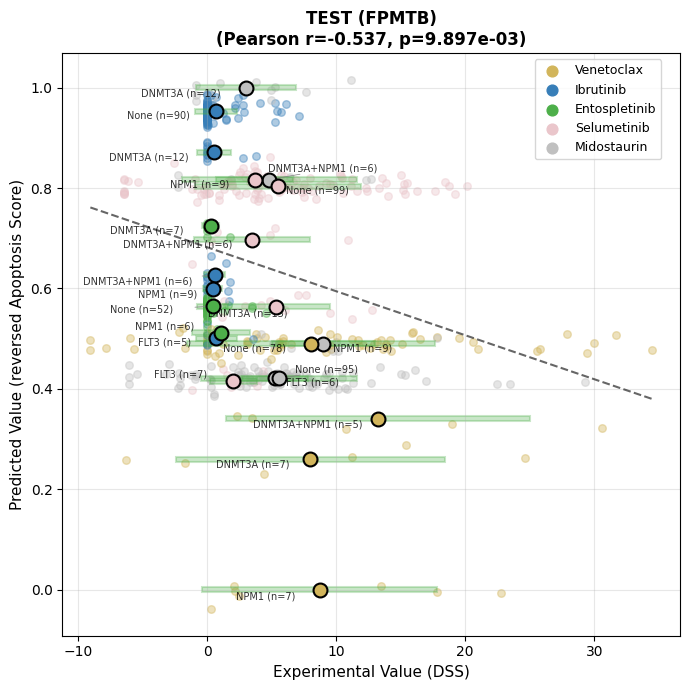

Saved: optimization_results/BeatAML_-AUC_5drugs_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_min5/prediction_vs_experimental_individual.png


In [58]:
pbn = KGBN.load_pbn_from_file('optimization_results/BeatAML_-AUC_5drugs_Waves1+2_AND+OR+IW/pbn.txt')
formula = KGBN.phenotype_scores(
    genes=pbn.nodeDict.keys(),
    simulation_results=None,
    phenotypes=['APOPTOSIS'],
    reversed=True
)
eval_result = KGBN.evaluate_pbn(pbn, 'inputs/FPMTB_sDSS_5drugs_min5.csv', 
    config=config, 
    Measured_formula=formula['APOPTOSIS'],
    normalize=True,
    output_dir='optimization_results/BeatAML_-AUC_5drugs_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_min5')

data_df = pd.read_csv('inputs/FPMTB_sDSS_5drugs_min5.csv')
expanded_plot(data_df, df_long, eval_result, drug2target, use_spearman=False, save_path='optimization_results/BeatAML_-AUC_5drugs_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_min5/prediction_vs_experimental_individual.png')

No initial state provided, using a random initial state
PBN loaded successfully. There are 24 genes in the network.
Path found for 1 phenotypes: ['APOPTOSIS']
Plot saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/FPMTB_sDSS_5drugs_min5/prediction_vs_experimental.png
Residual plot saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/FPMTB_sDSS_5drugs_min5/residual_analysis.png
Evaluation report saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/FPMTB_sDSS_5drugs_min5/evaluation_report.txt
Results exported to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/FPMTB_sDSS_5drugs_min5/detailed_results.csv
PBN saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/FPMTB_sDSS_5drugs_min5/pbn.txt
['None' 'FLT3' 'DNMT

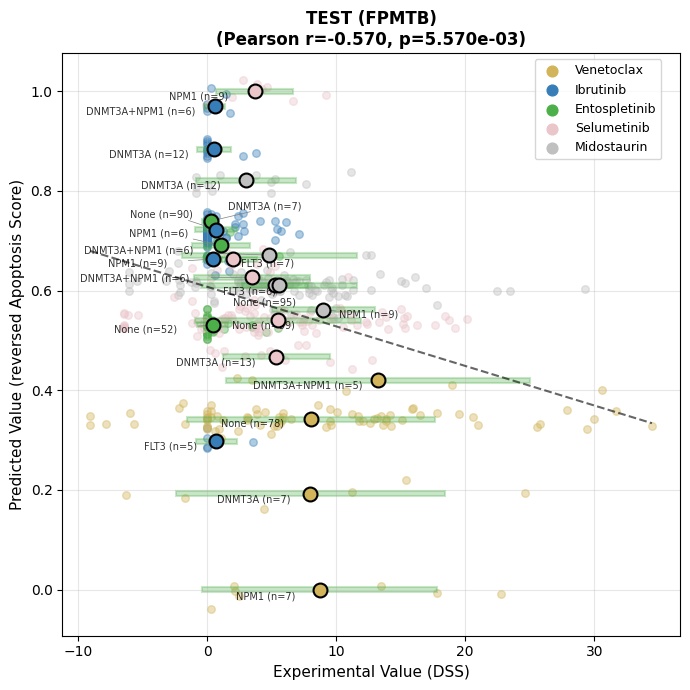

Saved: optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/FPMTB_sDSS_5drugs_min5/prediction_vs_experimental_individual.png


In [59]:
pbn = KGBN.load_pbn_from_file('optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/pbn.txt')
formula = KGBN.phenotype_scores(
    genes=pbn.nodeDict.keys(),
    simulation_results=None,
    phenotypes=['APOPTOSIS'],
    reversed=True
)
eval_result = KGBN.evaluate_pbn(pbn, 'inputs/FPMTB_sDSS_5drugs_min5.csv', 
    config=config, 
    Measured_formula=formula['APOPTOSIS'],
    normalize=True,
    output_dir='optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/FPMTB_sDSS_5drugs_min5')

data_df = pd.read_csv('inputs/FPMTB_sDSS_5drugs_min5.csv')
expanded_plot(data_df, df_long, eval_result, drug2target, use_spearman=False, save_path='optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW/FPMTB_sDSS_5drugs_min5/prediction_vs_experimental_individual.png')

## Extend to NRAS

In [60]:
gene_of_interest = ['FLT3','NPM1','DNMT3A','NRAS']

# Filter mutations to genes of interest
genes_to_use = df_mutation.index.intersection(gene_of_interest)
df_mut_filt = df_mutation.loc[genes_to_use]

# Build mutation_profile per sample (set of mutated genes)
mutation_profile = df_mut_filt.apply(
    lambda col: {gene for gene, val in col.items() if val == 1},
    axis=0
)

# Filter DSS to selected drugs
drugs_to_use = df_dss.index.intersection(drugs)
df_dss_filt = df_dss.loc[drugs_to_use]

# Long-format DSS: one row per (sample, drug)
df_long_nras = (
    df_dss_filt
    .reset_index()    
    .rename(columns={'index': 'drug'})
    .melt(id_vars='Drug_name',
          var_name='sample_id',
          value_name='DSS')
)

# drop missing DSS values
df_long_nras = df_long_nras.dropna(subset=['DSS'])

# Add mutation_profile column
df_long_nras['mutation_profile'] = df_long_nras['sample_id'].map(mutation_profile)
df_long_nras = df_long_nras.dropna(subset=['mutation_profile'])
df_long_nras['mutation_profile'].value_counts()


mutation_profile
{}                      469
{DNMT3A}                 53
{NRAS}                   44
{NPM1}                   43
{FLT3}                   30
{DNMT3A, NPM1}           28
{DNMT3A, FLT3}           21
{NPM1, FLT3}             18
{DNMT3A, NPM1, FLT3}     15
{DNMT3A, NRAS}           11
{NPM1, NRAS}              6
{DNMT3A, NPM1, NRAS}      5
Name: count, dtype: int64

In [61]:
create_FPMTB(df_long_nras, gene_of_interest = ['FLT3','NPM1','DNMT3A','NRAS'],
                            inhibitors=['Ibrutinib','Entospletinib','Venetoclax','Selumetinib','Midostaurin'],
                            drug2target=drug2target,
                            min_patients=5,
                            output_file='inputs/FPMTB_sDSS_5drugs_NRAS_min5.csv')


Generating data for 16 profiles × 5 drugs = 80 experiments
Not enough patients for Entospletinib {'FLT3'}, skipping...
Not enough patients for Venetoclax {'FLT3'}, skipping...
Not enough patients for Entospletinib {'NRAS'}, skipping...
Not enough patients for Ibrutinib {'NPM1', 'FLT3'}, skipping...
Not enough patients for Entospletinib {'NPM1', 'FLT3'}, skipping...
Not enough patients for Venetoclax {'NPM1', 'FLT3'}, skipping...
Not enough patients for Selumetinib {'NPM1', 'FLT3'}, skipping...
Not enough patients for Midostaurin {'NPM1', 'FLT3'}, skipping...
Not enough patients for Ibrutinib {'DNMT3A', 'FLT3'}, skipping...
Not enough patients for Entospletinib {'DNMT3A', 'FLT3'}, skipping...
Not enough patients for Venetoclax {'DNMT3A', 'FLT3'}, skipping...
Not enough patients for Selumetinib {'DNMT3A', 'FLT3'}, skipping...
Not enough patients for Midostaurin {'DNMT3A', 'FLT3'}, skipping...
Not enough patients for Entospletinib {'DNMT3A', 'NPM1'}, skipping...
Not enough patients for I

,Experiments,Stimuli,Stimuli_efficacy,Inhibitors,Inhibitors_efficacy,Measured_nodes,Measured_values,n_patients,std,drug
0,1,,,BTK,1,DSS,0.78,81,1.68,Ibrutinib
1,2,,,SYK,1,DSS,0.45,50,1.21,Entospletinib
2,3,,,BCL2,1,DSS,8.38,72,9.48,Venetoclax
3,4,,,"MAP2K1,MAP2K2","1,1",DSS,4.67,90,5.69,Selumetinib
4,5,,,"FLT3,KIT","1,1",DSS,5.83,86,6.15,Midostaurin
5,6,FLT3,1,BTK,1,DSS,0.72,5,1.61,Ibrutinib
6,7,FLT3,1,"MAP2K1,MAP2K2","1,1",DSS,2.02,7,1.81,Selumetinib
7,8,FLT3,1,"FLT3,KIT","1,1",DSS,5.27,6,2.54,Midostaurin
8,9,,,"BTK,NPM1","1,1",DSS,0.49,8,0.75,Ibrutinib
9,10,,,"NPM1,SYK","1,1",DSS,1.12,5,2.50,Entospletinib


No initial state provided, using a random initial state
PBN loaded successfully. There are 25 genes in the network.
Path found for 1 phenotypes: ['APOPTOSIS']
Plot saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_NRAS_min5/prediction_vs_experimental.png
Residual plot saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_NRAS_min5/residual_analysis.png
Evaluation report saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_NRAS_min5/evaluation_report.txt
Results exported to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_NRAS_min5/detailed_results.csv
PBN saved to /Users/luna/Desktop/KGBN/KGBN/manuscript/optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves

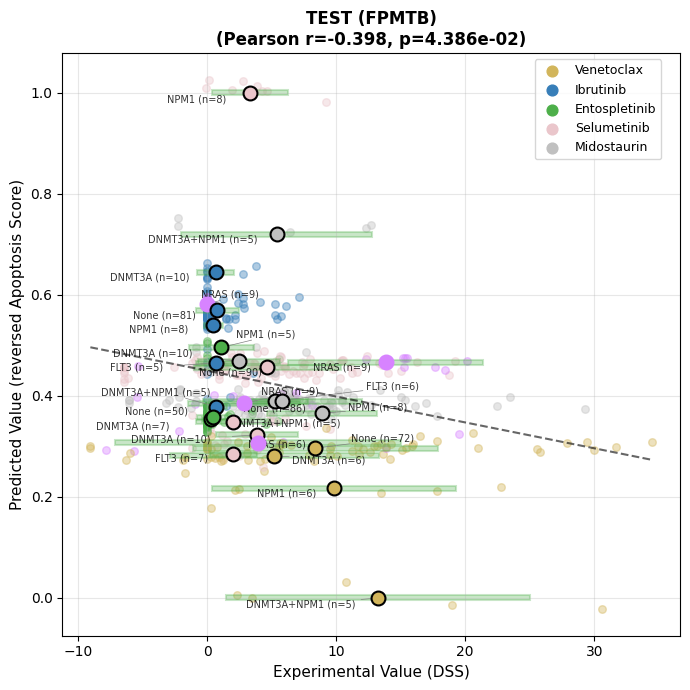

Saved: optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_NRAS_min5/prediction_vs_experimental_individual.png


In [62]:
pbn = KGBN.load_pbn_from_file('optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/pbn.txt')
formula = KGBN.phenotype_scores(
    genes=pbn.nodeDict.keys(),
    simulation_results=None,
    phenotypes=['APOPTOSIS'],
    reversed=True
)
eval_result = KGBN.evaluate_pbn(pbn, 'inputs/FPMTB_sDSS_5drugs_NRAS_min5.csv', 
    config=config, 
    Measured_formula=formula['APOPTOSIS'],
    normalize=True,
    output_dir='optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_NRAS_min5')

data_df = pd.read_csv('inputs/FPMTB_sDSS_5drugs_NRAS_min5.csv')
expanded_plot(data_df, df_long_nras, eval_result, drug2target, extended_gene = 'NRAS', use_spearman=False, save_path='optimization_results/BeatAML_-AUC_5drugs_NRAS_DAB_Waves1+2_AND+OR+IW/FPMTB_sDSS_5drugs_NRAS_min5/prediction_vs_experimental_individual.png')

# Sensitivity analysis

In [64]:
import sys
# import importlib
# importlib.reload(sys.modules['KGBN.sensitivity_analysis'])
from KGBN.sensitivity_analysis import (
    sensitivity_analysis, 
    plot_sensitivity_results,
    mse_sensitivity_analysis,
    plot_mse_sensitivity_results
)
config = {
            'sensitivity_method': 'morris',  # 'morris', or 'sobol'
            'morris_trajectories': 1000,    
            'sobol_samples': 512,
            'sobol_second_order': False,
            'parallel': True,  
            'n_workers': -1,
            'batch_size': 100,
            'seed': 9,  
            'steady_state': {
                'method': 'tsmc',
                'tsmc_params': {
                    'epsilon': 0.05, 
                    'r': 0.1, 
                    's': 0.85, 
                    'p_mir': 0.01, 
                    'initial_nsteps': 100, 
                    'max_iterations': 1000, 
                    'freeze_constant': True 
                },
            }
        }

formula = KGBN.phenotype_scores(
    genes=pbn.nodeDict.keys(),
    simulation_results=None,
    phenotypes=['APOPTOSIS'],
    reversed=True
)

Path found for 1 phenotypes: ['APOPTOSIS']


The following code has been run at UW Hyak. Results are saved in the corresponding folders.

In [ ]:
output_dir_1 = "optimization_results/BeatAML_-AUC_5drugs_Waves1+2_AND+OR+IW"
experiments_file_1 = "inputs/BeatAML_AUC_5drugs_Waves1+2.csv"
output_dir_2 = "optimization_results/BeatAML_-AUC_5drugs_Waves3+4_AND+OR+IW"
experiments_file_2 = "inputs/BeatAML_AUC_5drugs_Waves3+4.csv"

print("Sensitivity analysis___________________________________________")
print("Waves1+2_______________________________________________________")
pbn_1 = KGBN.load_pbn_from_file(os.path.join(output_dir_1,'pbn.txt'))

formula = KGBN.phenotype_scores(
    genes=pbn_1.nodeDict.keys(),
    simulation_results=None,
    phenotypes=['APOPTOSIS'],
    reversed=True
)
print(formula)

np.random.seed(9)
sens_results = sensitivity_analysis(pbn_1, experiments_file_1, config, 
    top_n=15,
    Measured_formula=formula['APOPTOSIS'],
    normalize=True)
sens_results['sensitivity_df'].to_csv(os.path.join(output_dir_1, "sensitivity_df.csv"), index=False)
plot_sensitivity_results(sens_results['sensitivity_df'], top_n=15, save_path=os.path.join(output_dir_1, "morris_sensitivity.png"))

print("Waves3+4_______________________________________________________")
pbn_2 = KGBN.load_pbn_from_file(os.path.join(output_dir_2,'pbn.txt'))

formula = KGBN.phenotype_scores(
    genes=pbn_2.nodeDict.keys(),
    simulation_results=None,
    phenotypes=['APOPTOSIS'],
    reversed=True
)
print(formula)

np.random.seed(9)
sens_results = sensitivity_analysis(pbn_2, experiments_file_2, config, 
    top_n=15,
    Measured_formula=formula['APOPTOSIS'],
    normalize=True)
sens_results['sensitivity_df'].to_csv(os.path.join(output_dir_2, "sensitivity_df.csv"), index=False)
plot_sensitivity_results(sens_results['sensitivity_df'], top_n=15, save_path=os.path.join(output_dir_2, "morris_sensitivity.png"))

print("MSE analysis___________________________________________")
print("Waves1+2_______________________________________________________")
pbn_1 = KGBN.load_pbn_from_file(os.path.join(output_dir_1,'pbn.txt'))

formula = KGBN.phenotype_scores(
    genes=pbn_1.nodeDict.keys(),
    simulation_results=None,
    phenotypes=['APOPTOSIS'],
    reversed=True
)
print(formula)

np.random.seed(9)
sens_results = mse_sensitivity_analysis(pbn_1, experiments_file_1, config, 
    top_n=15,
    Measured_formula=formula['APOPTOSIS'],
    normalize=True)
sens_results['sensitivity_df'].to_csv(os.path.join(output_dir_1, "mse_sensitivity_df.csv"), index=False)
plot_mse_sensitivity_results(sens_results['sensitivity_df'],sens_results['baseline_mse'], top_n=15, save_path=os.path.join(output_dir_1, "mse_sensitivity.png"))

print("Waves3+4_______________________________________________________")
pbn_2 = KGBN.load_pbn_from_file(os.path.join(output_dir_2,'pbn.txt'))

formula = KGBN.phenotype_scores(
    genes=pbn_2.nodeDict.keys(),
    simulation_results=None,
    phenotypes=['APOPTOSIS'],
    reversed=True
)
print(formula)

np.random.seed(9)
sens_results = mse_sensitivity_analysis(pbn_2, experiments_file_2, config, 
    top_n=15,
    Measured_formula=formula['APOPTOSIS'],
    normalize=True)
sens_results['sensitivity_df'].to_csv(os.path.join(output_dir_2, "mse_sensitivity_df.csv"), index=False)
plot_mse_sensitivity_results(sens_results['sensitivity_df'],sens_results['baseline_mse'], top_n=15, save_path=os.path.join(output_dir_2, "mse_sensitivity.png"))
